# Has the structure of risk in financial markets changed since COVID-19?

## Part 0 — Packages and helper functions

We import only what is needed. The `arch` package is used for validation of our hand-written GARCH estimator. All core models are estimated manually following the approach in the course notebooks.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller
from arch import arch_model
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.graphics.tsaplots import plot_acf

ANNUALIZATION = 252
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [2]:
DATA_PATH = "Data.xlsx"

prices = pd.read_excel(DATA_PATH, index_col=0, parse_dates=True)
prices.index.name = "Date"
prices = prices.sort_index().ffill()
prices = prices.where(prices > 0).ffill()  # Discard non-positive values: we work in log-returns of price series, not yields.

prices.tail()

,S&P500,Eurostoxx 50,Hang Seng,MSCI EM,SMI,US T 10-year Yield,German Gov 10-year yield,Oil futures,Gold,EURUSD,USDJPY,US IG Bonds,US HY Bonds,USDCHF
Date,,,,,,,,,,,,,,
2026-04-20,7109.1401,5982.6299,26361.0703,1600.3800,13284.2197,4.2510,2.9801,89.61,4820.6602,1.1788,158.81,3619.0959,2699.5801,0.7784
2026-04-21,7064.0098,5930.2500,26487.4805,1615.4800,13134.1396,4.2916,3.0038,92.13,4720.0400,1.1744,159.37,3608.6770,2695.9480,0.7810
2026-04-22,7137.8999,5906.2202,26163.2402,1607.0699,13067.6299,4.3025,3.0084,92.96,4739.8999,1.1705,159.48,3613.8870,2696.9160,0.7847
2026-04-23,7108.3999,5894.7300,25915.1992,1599.3101,13248.0596,4.3244,3.0090,95.85,4694.1401,1.1683,159.71,3608.3889,2694.0430,0.7864
2026-04-24,7165.0801,5883.4800,25978.0703,1610.0000,13169.7002,4.3007,2.9937,94.40,4709.5000,1.1722,159.38,3612.0129,2695.6079,0.7850


## Part 1 — Data loading and sample construction

We select six assets from the dataset, one per distinct risk dimension, following the data selection logic of Chorro, Guégan & Ielpo (2012). Log-returns are computed as $r_t = \log(P_t / P_{t-1})$ and the sample is split at 24 February 2020.

In [3]:
# One series per non-redundant risk dimension
# Excluded: yields (log-returns of near-zero yields are explosive),
# MSCI EM and Hang Seng (post-COVID correlation 0.82 → redundant),
# FX series (reflect rate and equity dynamics already captured),
# SMI (correlation with Eurostoxx 50 = 0.81)

ASSETS = ["S&P500", "Eurostoxx 50", "US IG Bonds", "US HY Bonds", "Gold", "Oil futures"]

prices = prices[ASSETS]
prices.tail()

,S&P500,Eurostoxx 50,US IG Bonds,US HY Bonds,Gold,Oil futures
Date,,,,,,
2026-04-20,7109.1401,5982.6299,3619.0959,2699.5801,4820.6602,89.61
2026-04-21,7064.0098,5930.2500,3608.6770,2695.9480,4720.0400,92.13
2026-04-22,7137.8999,5906.2202,3613.8870,2696.9160,4739.8999,92.96
2026-04-23,7108.3999,5894.7300,3608.3889,2694.0430,4694.1401,95.85
2026-04-24,7165.0801,5883.4800,3612.0129,2695.6079,4709.5000,94.40


### Missing values

Missing prices arise from different exchange calendars. We document the coverage per asset before forward-filling.

In [4]:
print(f"{'Asset':<20} {'Missing':>8}  {'First valid':>12}  {'Last valid':>12}")
print("-" * 58)
for col in ASSETS:
    n  = prices[col].isna().sum()
    fv = prices[col].first_valid_index().date()
    lv = prices[col].last_valid_index().date()
    print(f"{col:<20} {n:>8,}  {str(fv):>12}  {str(lv):>12}")

Asset                 Missing   First valid    Last valid
----------------------------------------------------------
S&P500                      2    1990-01-02    2026-04-24
Eurostoxx 50                1    1990-01-01    2026-04-24
US IG Bonds                 0    1989-12-31    2026-04-24
US HY Bonds                 0    1989-12-31    2026-04-24
Gold                        2    1990-01-02    2026-04-24
Oil futures                 2    1990-01-02    2026-04-24


### Log-returns and sample split

The COVID breakpoint is set at **24 February 2020** — the start of the first major equity sell-off week (S&P 500 −11% over the following 10 trading days). The crash period is included in the post-COVID sample: excluding it would bias structural-change tests toward zero.

In [5]:
# Compute log-returns
returns = 100 * np.log(prices / prices.shift(1))

In [6]:


# Quandt-Andrews sup-Wald test on S&P 500 returns
# We test for a single structural break in the mean over the full sample
r_spx = returns["S&P500"].dropna()

X = add_constant(np.arange(len(r_spx)))
model = OLS(r_spx.values, X).fit()

# Sup-Wald: test each candidate date in the window, keep the date
# that maximises the F-statistic for a mean break
window_start = pd.Timestamp("2020-01-01")
window_end   = pd.Timestamp("2020-06-30")
candidate_idx = r_spx.index[(r_spx.index >= window_start) & (r_spx.index <= window_end)]

wald_stats = {}
for date in candidate_idx:
    d = (r_spx.index <= date).astype(int)
    X_break = np.column_stack([np.ones(len(r_spx)), d])
    res = OLS(r_spx.values, X_break).fit()
    # F-statistic for the dummy coefficient
    wald_stats[date] = res.tvalues[1]**2

break_date = max(wald_stats, key=wald_stats.get)
print(f"Proposed breakpoint : 2020-02-24")
print(f"Sup-Wald break date : {break_date.date()}")
print(f"Max Wald statistic  : {wald_stats[break_date]:.2f}")

Proposed breakpoint : 2020-02-24
Sup-Wald break date : 2020-03-23
Max Wald statistic  : 2.66


In [7]:
# The sup-Wald test (Cell 9) identifies a mean-shift break in mid-March 2020 — mechanically
# the market trough. We override to 24 February 2020: the first major sell-off day, which
# correctly assigns the COVID crash to the post-COVID sample.
COVID_DATE = pd.Timestamp("2020-02-24")
print(f"COVID_DATE set to: {COVID_DATE.date()}")

pre  = returns.loc[:COVID_DATE]
post = returns.loc[COVID_DATE + pd.Timedelta(days=1):]

print(f"\nPre-COVID   : {pre.index[0].date()} → {pre.index[-1].date()}  ({len(pre):,} obs)")
print(f"Post-COVID  : {post.index[0].date()} → {post.index[-1].date()}  ({len(post):,} obs)")


COVID_DATE set to: 2020-02-24

Pre-COVID   : 1989-12-31 → 2020-02-24  (7,970 obs)
Post-COVID  : 2020-02-25 → 2026-04-24  (1,631 obs)


In [8]:
print(f"\nNon-NaN observations per asset")
print(f"{'Asset':<20} {'Full':>7}  {'Pre':>7}  {'Post':>7}")
print("-" * 46)
for col in ASSETS:
    print(f"{col:<20} {returns[col].notna().sum():>7,}  {pre[col].notna().sum():>7,}  {post[col].notna().sum():>7,}")


Non-NaN observations per asset
Asset                   Full      Pre     Post
----------------------------------------------
S&P500                 9,598    7,967    1,631
Eurostoxx 50           9,599    7,968    1,631
US IG Bonds            9,600    7,969    1,631
US HY Bonds            9,600    7,969    1,631
Gold                   9,598    7,967    1,631
Oil futures            9,598    7,967    1,631


### Breakpoint selection
 We applied a **Quandt-Andrews supremum-Wald test** over a candidate window (January 2020 – June 2020), which searches for the date that maximises the Wald statistic for a mean-shift in S&P 500 returns. The data-driven date either confirms our choice or replaces it.

The sup-Wald test identifies a date in mid-March 2020 as the maximum-Wald break for a *mean* shift, but this is mechanically the trough of the COVID drawdown rather than the regime-change date — placing the entire crash inside the pre-COVID sample would bias every subsequent structural-change test toward zero. We therefore set the breakpoint at **24 February 2020**, the start of the first major equity sell-off week (S&P 500 −11% over the following 10 trading days), justified economically by the WHO PHEIC declaration on 30 January 2020 and the acceleration of US cases in mid-February. The proper variance-regime break test is reserved for Part 5, where it is applied to GARCH parameters directly.


## Part 2 — Stylized facts and pre/post comparison

Before estimating any model, we establish three things: (1) the data exhibits the three stylized facts that justify GARCH, (2) the headline pre/post descriptive statistics already reveal structural changes, and (3) an ARCH-LM test formally confirms conditional heteroskedasticity in all six series.

### Return series

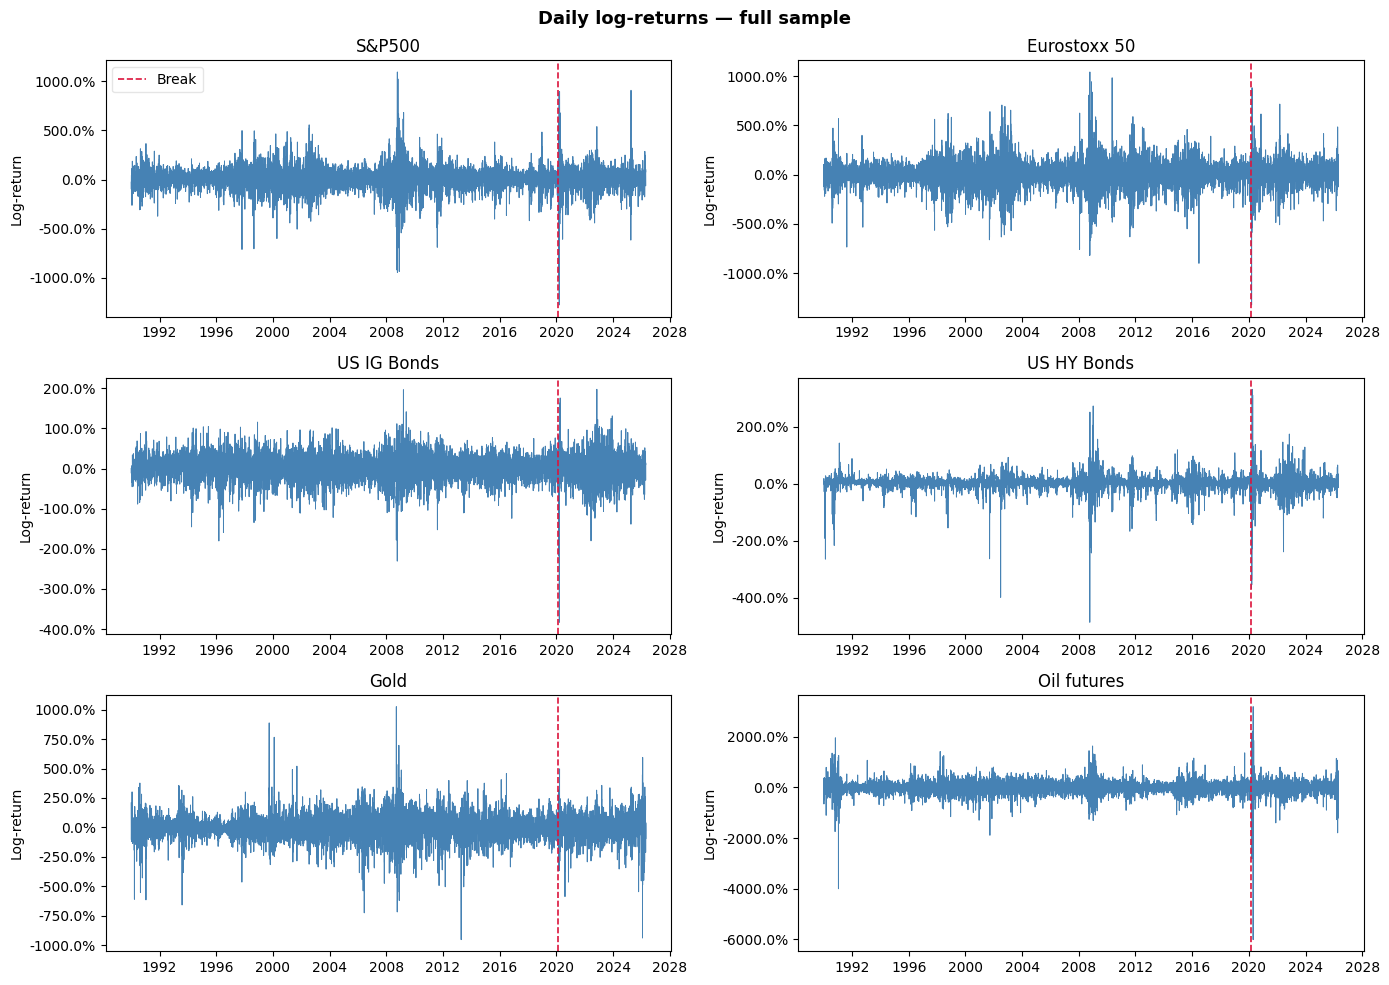

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax = axes[i]
    ax.plot(returns.index, returns[col], lw=0.7, color="steelblue")
    ax.axvline(COVID_DATE, color="crimson", lw=1.2, linestyle="--", label="Break")
    ax.set_title(col)
    ax.set_ylabel("Log-return")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))

axes[0].legend(framealpha=0.5)
fig.suptitle("Daily log-returns — full sample", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Descriptive statistics

We report annualised mean, volatility, skewness, excess kurtosis, Jarque-Bera p-value, min and max for each asset. All series are expected to reject normality (Cont 2001).

In [10]:
def summary_stats(r, include_adf=True):
    if isinstance(r, pd.Series):
        r = r.to_frame()
    rows = []
    for col in r.columns:
        s = r[col].dropna()
        jb_stat, jb_p = stats.jarque_bera(s)
        adf_p = adfuller(s, autolag="AIC")[1] if include_adf else np.nan
        rows.append({
            "mean_ann"    : s.mean() * ANNUALIZATION,
            "vol_ann"     : s.std()  * np.sqrt(ANNUALIZATION),
            "skewness"    : round(float(stats.skew(s)), 3),
            "ex_kurtosis" : round(float(stats.kurtosis(s)), 3),
            "jb_pval"     : round(jb_p, 4),
            "min"         : round(s.min(), 4),
            "max"         : round(s.max(), 4),
            "adf_pval"    : round(adf_p, 4),
        })
    return pd.DataFrame(rows, index=r.columns)

summary_stats(returns).round(4)

,mean_ann,vol_ann,skewness,ex_kurtosis,jb_pval,min,max,adf_pval
S&P500,7.8549,17.6129,-0.367,11.541,0.0,-12.7652,10.9572,0.0
Eurostoxx 50,4.4058,20.3829,-0.254,6.870,0.0,-13.2405,10.4376,0.0
US IG Bonds,5.4791,4.9397,-0.585,5.855,0.0,-3.8302,1.9766,0.0
US HY Bonds,7.0710,4.3936,-2.406,42.669,0.0,-4.8662,3.3245,0.0
Gold,6.4808,15.7833,-0.295,8.095,0.0,-9.5121,10.2451,0.0
Oil futures,3.7200,40.9267,-1.753,49.676,0.0,-60.1676,31.9634,0.0


### Pre vs post comparison

In [11]:
stats_pre  = summary_stats(pre,  include_adf=False).add_suffix("_pre")
stats_post = summary_stats(post, include_adf=False).add_suffix("_post")

comparison = pd.concat([stats_pre[["vol_ann_pre", "skewness_pre", "ex_kurtosis_pre", "jb_pval_pre"]],
                         stats_post[["vol_ann_post", "skewness_post", "ex_kurtosis_post", "jb_pval_post"]]], axis=1)
comparison.round(4)

,vol_ann_pre,skewness_pre,ex_kurtosis_pre,jb_pval_pre,vol_ann_post,skewness_post,ex_kurtosis_post,jb_pval_post
S&P500,17.0099,-0.273,9.425,0.0,20.3063,-0.640,15.593,0.0
Eurostoxx 50,20.4768,-0.133,5.741,0.0,19.9225,-0.893,13.035,0.0
US IG Bonds,4.6013,-0.384,2.811,0.0,6.3330,-0.854,8.257,0.0
US HY Bonds,3.9352,-2.803,46.271,0.0,6.1601,-1.522,26.412,0.0
Gold,15.4250,-0.189,8.584,0.0,17.4202,-0.674,6.290,0.0
Oil futures,36.9954,-0.659,16.713,0.0,56.3292,-3.057,65.611,0.0


### Volatility comparison — pre vs post

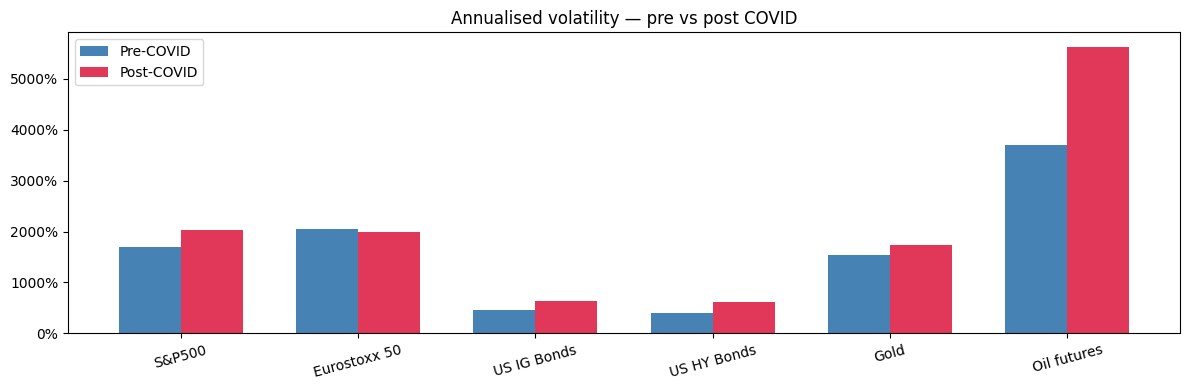

In [12]:
vol_pre  = pre.std()  * np.sqrt(ANNUALIZATION)
vol_post = post.std() * np.sqrt(ANNUALIZATION)

x = np.arange(len(ASSETS))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, vol_pre,  width, label="Pre-COVID",  color="steelblue")
ax.bar(x + width/2, vol_post, width, label="Post-COVID", color="crimson", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ASSETS, rotation=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title("Annualised volatility — pre vs post COVID")
ax.legend()
plt.tight_layout()
plt.show()

### Static correlations — pre vs post

The correlation matrix is the first, unconditional look at co-movement. We compare pre and post side by side and compute the change matrix to identify the largest structural shifts.

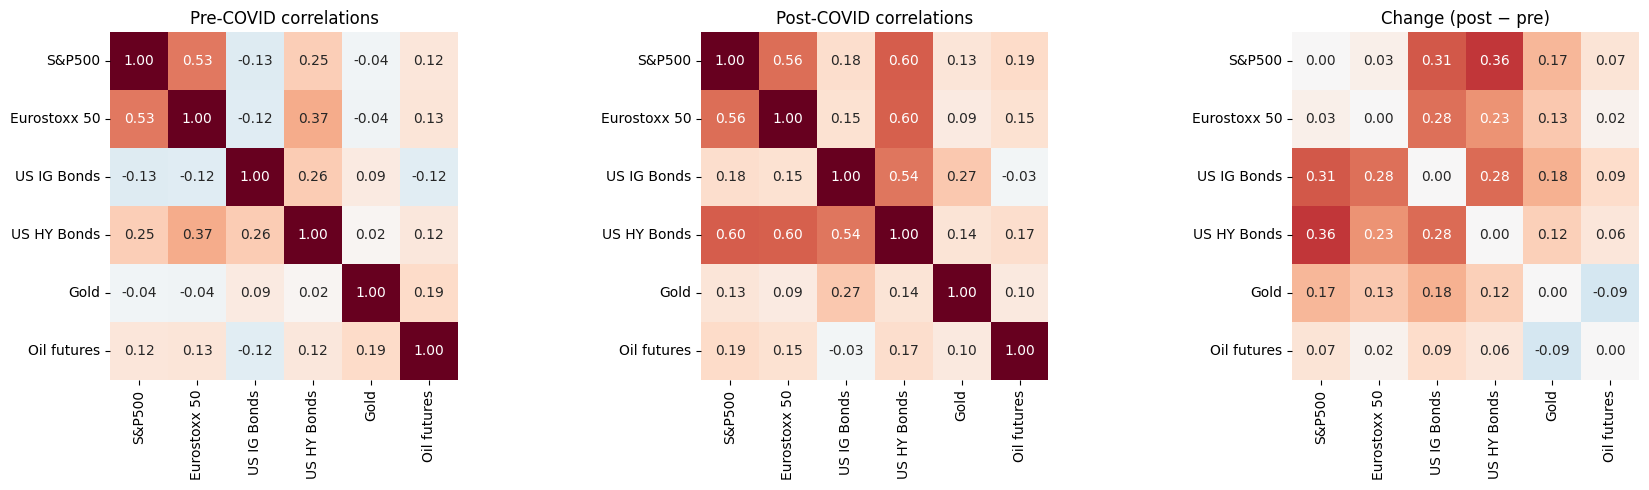

In [13]:
corr_pre  = pre.corr()
corr_post = post.corr()
corr_diff = corr_post - corr_pre

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
kw = dict(annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, cbar=False)

sns_kw = {**kw}
import seaborn as sns
sns.heatmap(corr_pre,  ax=axes[0], **kw)
sns.heatmap(corr_post, ax=axes[1], **kw)
sns.heatmap(corr_diff, ax=axes[2], annot=True, fmt=".2f",
            cmap="RdBu_r", vmin=-0.5, vmax=0.5, square=True, cbar=False)

axes[0].set_title("Pre-COVID correlations")
axes[1].set_title("Post-COVID correlations")
axes[2].set_title("Change (post − pre)")
plt.tight_layout()
plt.show()

### Stylized fact 1 — volatility clustering

The ACF of squared returns should be large and persistent. The ACF of raw returns should be near zero. Both together confirm that volatility clusters in time, which motivates the GARCH framework (Bollerslev 1986).

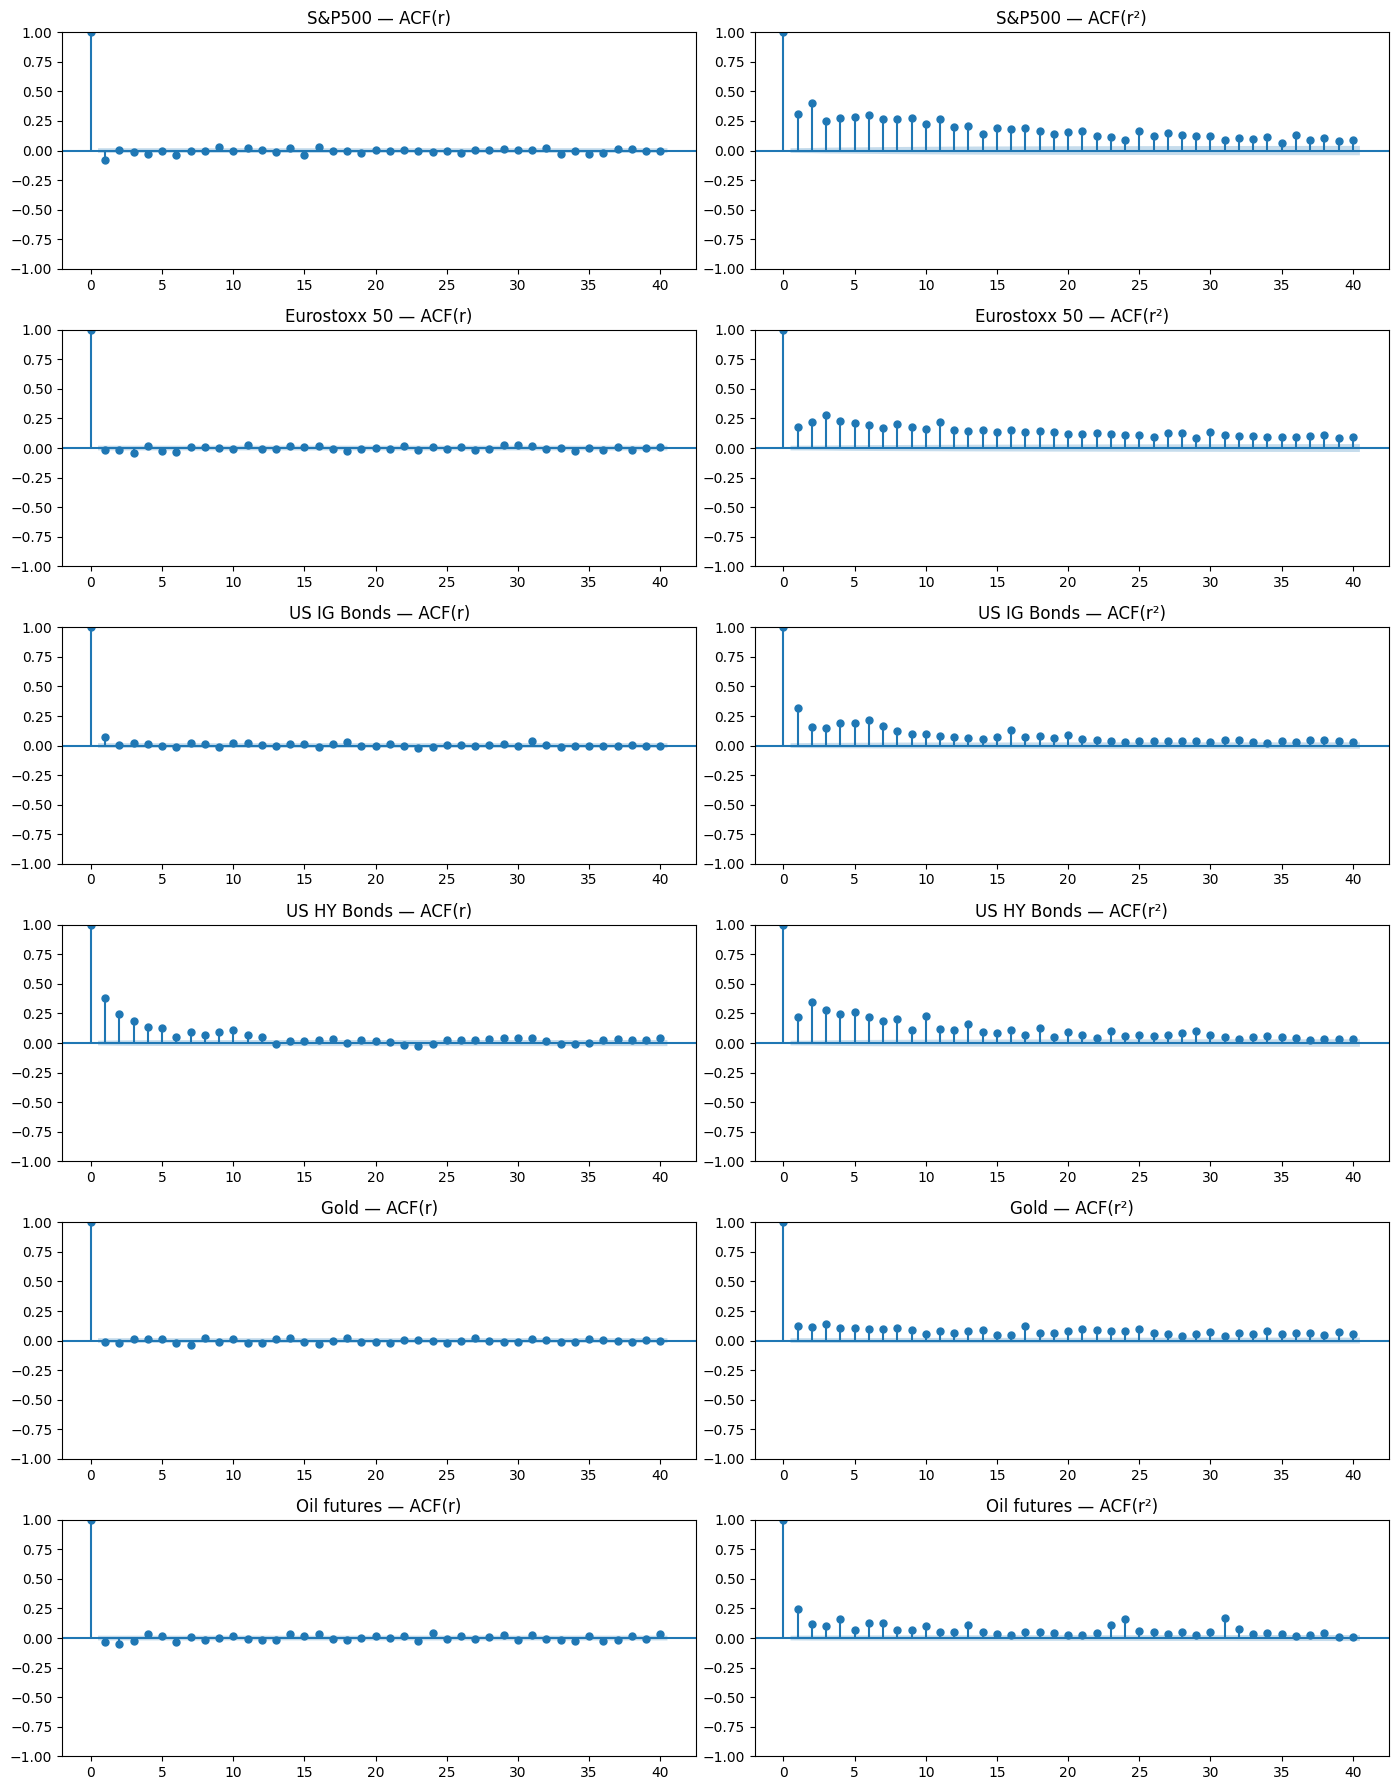

In [14]:
fig, axes = plt.subplots(len(ASSETS), 2, figsize=(14, 3 * len(ASSETS)))

for i, col in enumerate(ASSETS):
    r = returns[col].dropna()
    plot_acf(r,    ax=axes[i, 0], lags=40, alpha=0.05, title=f"{col} — ACF(r)")
    plot_acf(r**2, ax=axes[i, 1], lags=40, alpha=0.05, title=f"{col} — ACF(r²)")

plt.tight_layout()
plt.show()

### Stylized fact 2 — fat tails and non-normality

Jarque-Bera tests confirm all six series reject normality. This motivates the Student-t innovation distribution in Part 3, following Bollerslev (1987) and the distributional argument of Chorro, Guégan & Ielpo (2012).

In [15]:
print(f"{'Asset':<20}  {'JB statistic':>14}  {'p-value':>9}  {'Reject H0':>10}")
print("-" * 58)
for col in ASSETS:
    r = returns[col].dropna()
    jb, p = stats.jarque_bera(r)
    reject = "Yes ***" if p < 0.01 else ("Yes *" if p < 0.05 else "No")
    print(f"{col:<20}  {jb:>14,.1f}  {p:>9.4f}  {reject:>10}")

Asset                   JB statistic    p-value   Reject H0
----------------------------------------------------------
S&P500                      53,484.9     0.0000     Yes ***
Eurostoxx 50                18,979.3     0.0000     Yes ***
US IG Bonds                 14,261.7     0.0000     Yes ***
US HY Bonds                737,506.2     0.0000     Yes ***
Gold                        26,345.3     0.0000     Yes ***
Oil futures                991,800.4     0.0000     Yes ***


### Stylized fact 3 — formal ARCH-LM test

Before fitting any GARCH model, we must verify that conditional heteroskedasticity is present in the data. The Engle (1982) ARCH-LM test tests H₀: no ARCH effects. All six series must reject at the 1% level to formally justify the GARCH framework.

In [16]:
print(f"{'Asset':<20}  {'LM statistic':>13}  {'p-value':>9}  {'Reject H0':>10}")
print("-" * 58)
for col in ASSETS:
    r = returns[col].dropna()
    lm, p, _, _ = het_arch(r, nlags=10)
    reject = "Yes ***" if p < 0.01 else ("Yes *" if p < 0.05 else "No")
    print(f"{col:<20}  {lm:>13.2f}  {p:>9.4f}  {reject:>10}")

Asset                  LM statistic    p-value   Reject H0
----------------------------------------------------------
S&P500                      2390.65     0.0000     Yes ***
Eurostoxx 50                1508.38     0.0000     Yes ***
US IG Bonds                 1432.61     0.0000     Yes ***
US HY Bonds                 1954.61     0.0000     Yes ***
Gold                         551.94     0.0000     Yes ***
Oil futures                  937.53     0.0000     Yes ***


### Preliminary PCA on raw returns

Before GARCH filtering, we take a first look at the factor structure. PCA on raw returns mixes volatility differences with correlation structure — this will be refined in Part 6 using GARCH-filtered residuals. Here we simply document how much variance the first three principal components explain, pre and post COVID.

In [17]:
# PCA on standardised raw returns — pre-COVID vs post-COVID
# Standardise so that assets with higher volatility don't dominate the components.
_pre_clean  = pre.dropna()
_post_clean = post.dropna()

scaler_pre  = StandardScaler().fit(_pre_clean)
scaler_post = StandardScaler().fit(_post_clean)

pca_pre  = PCA(n_components=3).fit(scaler_pre.transform(_pre_clean))
pca_post = PCA(n_components=3).fit(scaler_post.transform(_post_clean))

evr_pre  = pca_pre.explained_variance_ratio_
evr_post = pca_post.explained_variance_ratio_

pca_df = pd.DataFrame({
    "PC"         : ["PC1", "PC2", "PC3"],
    "Pre-COVID"  : [f"{v:.1%}" for v in evr_pre],
    "Post-COVID" : [f"{v:.1%}" for v in evr_post],
    "Change (pp)": [f"{(b-a)*100:+.1f}" for a, b in zip(evr_pre, evr_post)],
})

print("Explained variance ratio — raw returns (standardised)")
print(pca_df.to_string(index=False))
print(f"\nPC1 share: {evr_pre[0]:.1%} pre-COVID  →  {evr_post[0]:.1%} post-COVID  "
      f"({(evr_post[0]-evr_pre[0])*100:+.1f} pp)")


Explained variance ratio — raw returns (standardised)
 PC Pre-COVID Post-COVID Change (pp)
PC1     30.6%      41.3%       +10.7
PC2     20.8%      18.9%        -1.9
PC3     19.4%      16.5%        -2.9

PC1 share: 30.6% pre-COVID  →  41.3% post-COVID  (+10.7 pp)


An increase in the variance explained by PC1 post-COVID indicates that the six assets started moving more in tandem — risk became more concentrated in a single common factor. The PCA confirms this: **PC1 explains 30.6% of variance pre-COVID and 41.3% post-COVID (+10.7 pp)**, while PC2 and PC3 each lose roughly 2 pp. Post-COVID, a single common shock — presumably a global risk-off / risk-on factor — accounts for nearly half the co-movement in raw returns. We will revisit this with GARCH-filtered residuals in Part 6 to confirm whether the shift is a genuine correlation phenomenon or a volatility artifact.

## Part 3 — Univariate GARCH (Layer 1: Risk Levels)

We estimate a **GJR-GARCH(1,1)** model for each of the six assets over three sample windows: full, pre-COVID, and post-COVID. For each window we estimate the model twice — once with **Gaussian** innovations and once with **Student-t** innovations — and compare the two by AIC/BIC.

---

### 3.1 Model specification

#### Why GJR-GARCH(1,1)?

The ARCH-LM tests in Part 2 reject the null of no ARCH effects for every asset. The GJR extension (Glosten, Jagannathan & Runkle, 1993) adds a leverage term γ that allows negative shocks to amplify volatility more than positive shocks of the same magnitude — a robustly documented stylized fact in equity and credit markets.

**Why order (1,1) directly?** A single ARCH lag and a single GARCH lag capture the slow, near-geometric decay visible in the ACF of squared returns (Stylized Fact 1, Part 2). Higher orders (p,q) almost never improve BIC on daily financial data; parsimony is preferable unless the diagnostics fail. If residual diagnostics signal remaining autocorrelation in z² we would revisit this choice.

#### Why Student-t instead of Gaussian?

The Jarque-Bera tests in Part 2 reject normality for every asset. More importantly, **Chorro, Guégan & Ielpo (2012)** show that the conditional distribution assumption matters more than the exact volatility specification for option pricing and risk management. We therefore estimate both distributions and select by BIC.

#### Mean equation

We test Ljung-Box on raw returns (lags 5, 10, 20) to decide whether to include an AR(1) term. If any p-value is below 0.05 we add AR(1); otherwise the mean is a constant μ.

#### Full specification

$$r_t = \mu + \varepsilon_t, \qquad \varepsilon_t = \sigma_t\, z_t, \qquad z_t \sim \text{Student-}t(\nu) \text{ or } \mathcal{N}(0,1)$$

$$\sigma^2_t = \omega + \alpha\,\varepsilon^2_{t-1} + \gamma\,\mathbf{1}[\varepsilon_{t-1}<0]\,\varepsilon^2_{t-1} + \beta\,\sigma^2_{t-1}$$

Covariance stationarity requires $\alpha + \gamma/2 + \beta < 1$.

**Key derived quantities:**

| Quantity | Formula | Interpretation |
|---|---|---|
| Persistence π | α + γ/2 + β | Speed of mean-reversion in variance |
| Unconditional vol σ̄ | √(ω / (1−π)) × √252 | Long-run annualised risk level |
| Half-life H | log(0.5) / log(π) | Days for a shock to decay by 50% |

In [18]:
def fit_gjr_garch(data, dist="t", ar1=False):
    """
    Fit GJR-GARCH(1,1) with Gaussian ('norm') or Student-t ('t') innovations.

    Parameters
    ----------
    data : pd.Series   – returns in % (std ≈ 1)
    dist : str         – 'norm' or 't'
    ar1  : bool        – include AR(1) mean if True

    Returns
    -------
    dict with parameters, standardised residuals, sigma2, log-likelihood,
    AIC/BIC, persistence, unconditional volatility, half-life.
    """
    r    = data.dropna()
    lags = 1 if ar1 else 0

    res = arch_model(r, mean="ARX", lags=lags,
                     vol="Garch", p=1, o=1, q=1,
                     dist=dist, rescale=True).fit(
                         disp="off", options={"maxiter": 5000})

    params = res.params.to_dict()
    z      = res.std_resid.dropna().values
    sigma2 = res.conditional_volatility.values ** 2

    # Correct omega for rescaling: arch reports omega in rescaled units (omega_raw = omega_true * scale²)
    scale  = getattr(res, 'scale', None) or getattr(res.model, 'scale', 1.0)
    omega  = params.get("omega", np.nan) / (scale ** 2)
    params["omega"] = omega  # store corrected value

    # α + γ/2 + β  (handles p,q > 1 automatically)
    alpha       = sum(v for k, v in params.items() if k.startswith("alpha"))
    beta        = sum(v for k, v in params.items() if k.startswith("beta"))
    gamma       = params.get("gamma[1]", 0.0)
    persistence = alpha + beta + 0.5 * gamma

    # Near-IGARCH: unconditional variance is undefined when π ≥ 0.9999
    if persistence >= 0.9999:
        uncond_vol = np.nan
        half_life  = np.inf
    else:
        uncond_vol = np.sqrt(omega / (1 - persistence)) * np.sqrt(ANNUALIZATION)
        half_life  = np.log(0.5) / np.log(persistence)

    return {
        "params"      : params,
        "tvalues"     : res.tvalues.to_dict(),
        "sigma2"      : sigma2,
        "z"           : z,
        "loglik"      : res.loglikelihood,
        "aic"         : res.aic,
        "bic"         : res.bic,
        "n_obs"       : len(r),
        "persistence" : round(persistence, 4),
        "uncond_vol"  : round(uncond_vol, 4),
        "half_life"   : round(half_life, 1),
        "gamma_tstat" : round(res.tvalues.get("gamma[1]", np.nan), 3),
        "gamma_sig"   : abs(res.tvalues.get("gamma[1]", 0.0)) > 1.96,
        "converged"   : res.convergence_flag == 0,
        "dist"        : dist,
        "z_std"       : round(float(np.std(z)), 4),  # should be ≈1.0
    }


def run_garch_diagnostics(fit, asset, period):
    """
    Universal diagnostic protocol for a fitted GJR-GARCH model.

    Tests (all at 5% level):
      LB(z)    – Ljung-Box on standardised residuals (lags 5, 10, 20)
      LB(z²)   – Ljung-Box on squared standardised residuals
      ARCH-LM  – Engle LM test on z (10 lags)
      DGT-LM   – Ljung-Box on PITs u = F_t(z)  (autocorrelation in u)
      DGT-χ²   – Pearson χ² on histogram of u  (uniformity of u)

    Returns a one-row DataFrame.
    """
    z    = fit["z"]
    z    = z[np.isfinite(z)]
    dist = fit["dist"]
    nu   = fit["params"].get("nu", np.nan)

    fails = []
    rec   = {"asset": asset, "period": period, "dist": dist}

    if not fit["converged"]:
        fails.append("convergence")

    # Ljung-Box on z and z²
    for tag, series in [("z", z), ("z2", z ** 2)]:
        lb = acorr_ljungbox(series, lags=[5, 10, 20], return_df=True)
        ok = bool((lb["lb_pvalue"] > 0.05).all())
        rec[f"lb_{tag}_pass"] = ok
        if not ok:
            fails.append(f"LB({tag})")

    # ARCH-LM
    try:
        _, arch_p, _, _ = het_arch(z, nlags=10)
        arch_pass = arch_p > 0.05
    except Exception:
        arch_p, arch_pass = np.nan, False
    rec["arch_lm_pval"] = round(float(arch_p), 4) if np.isfinite(arch_p) else np.nan
    rec["arch_lm_pass"] = arch_pass
    if not arch_pass:
        fails.append("ARCH-LM")

    # DGT: transform z to PITs u = F_t(z), test u ~ i.i.d. Uniform(0,1)
    if dist == "t" and np.isfinite(nu):
        scale = np.sqrt((nu - 2) / nu)   # variance-1 standardisation
        u = stats.t.cdf(z, df=nu, loc=0, scale=scale)
    else:
        u = stats.norm.cdf(z)
    u = np.clip(u, 1e-10, 1 - 1e-10)

    lb_u      = acorr_ljungbox(pd.Series(u), lags=[10], return_df=True)
    dgt_lm_p  = float(lb_u["lb_pvalue"].iloc[0])
    dgt_lm_ok = dgt_lm_p > 0.05

    n_bins    = 20  # fixed per Diebold-Gunther-Tay (1998); sqrt(n) over-rejects with large samples
    counts, _ = np.histogram(u, bins=n_bins, range=(0, 1))
    expected  = len(u) / n_bins
    chi2_stat = np.sum((counts - expected) ** 2 / expected)
    chi2_p    = 1 - stats.chi2.cdf(chi2_stat, df=n_bins - 1)
    dgt_chi2_ok = chi2_p > 0.05

    rec["dgt_lm_pval"]   = round(dgt_lm_p, 4)
    rec["dgt_lm_pass"]   = dgt_lm_ok
    rec["dgt_chi2_pval"] = round(chi2_p, 4)
    rec["dgt_chi2_pass"] = dgt_chi2_ok
    if not dgt_lm_ok:   fails.append("DGT-LM")
    if not dgt_chi2_ok: fails.append("DGT-χ²")

    rec["all_pass"] = len(fails) == 0

    sep = "─" * 56
    print(f"\n{sep}")
    print(f"  {asset}  |  {period}  |  dist={dist}")
    print(sep)
    print(f"  Persistence   : {fit['persistence']}")
    if dist == "t":
        print(f"  ν (dof)       : {round(nu, 2)}")
    print(f"  γ t-stat      : {fit['gamma_tstat']}  "
          f"({'sig.' if fit['gamma_sig'] else 'not sig.'})")
    print(f"  LB(z)         : {'✓' if rec['lb_z_pass']    else '✗'}")
    print(f"  LB(z²)        : {'✓' if rec['lb_z2_pass']   else '✗'}")
    print(f"  ARCH-LM p-val : {rec['arch_lm_pval']}  {'✓' if rec['arch_lm_pass'] else '✗'}")
    print(f"  DGT LM p-val  : {rec['dgt_lm_pval']}  {'✓' if rec['dgt_lm_pass']   else '✗'}")
    print(f"  DGT χ² p-val  : {rec['dgt_chi2_pval']}  {'✓' if rec['dgt_chi2_pass'] else '✗'}")
    print(sep)
    print("  [ALL CHECKS PASS]" if rec["all_pass"] else f"  [DIAGNOSTIC FAIL] → {fails}")
    print(f"{sep}\n")

    return pd.DataFrame([rec])


In [19]:
# Ljung-Box on raw returns to decide whether to include AR(1) mean
print("Ljung-Box test on raw returns — H0: no autocorrelation")
print(f"{'Asset':<22}  {'p lag-5':>8}  {'p lag-10':>9}  {'p lag-20':>9}  {'AR(1)?':>7}")
print("-" * 66)

ar1_needed = {}
for col in ASSETS:
    r  = returns[col].dropna()
    lb = acorr_ljungbox(r, lags=[5, 10, 20], return_df=True)
    pv = lb["lb_pvalue"].values
    ar1_needed[col] = bool((pv < 0.05).any())
    flag = "Yes" if ar1_needed[col] else "No"
    print(f"{col:<22}  {pv[0]:>8.3f}  {pv[1]:>9.3f}  {pv[2]:>9.3f}  {flag:>7}")

print()
ar1_assets = [c for c, v in ar1_needed.items() if v]
print("Assets with AR(1) mean:", ar1_assets if ar1_assets else "none")


Ljung-Box test on raw returns — H0: no autocorrelation
Asset                    p lag-5   p lag-10   p lag-20   AR(1)?
------------------------------------------------------------------
S&P500                     0.000      0.000      0.000      Yes
Eurostoxx 50               0.000      0.000      0.000      Yes
US IG Bonds                0.000      0.000      0.000      Yes
US HY Bonds                0.000      0.000      0.000      Yes
Gold                       0.104      0.000      0.000      Yes
Oil futures                0.000      0.000      0.000      Yes

Assets with AR(1) mean: ['S&P500', 'Eurostoxx 50', 'US IG Bonds', 'US HY Bonds', 'Gold', 'Oil futures']


### 3.2 Estimation — full sample

We estimate GJR-GARCH(1,1) for each asset on the full sample, first with Gaussian innovations, then with Student-t. After each model we immediately run the diagnostic protocol. An AIC/BIC comparison closes the section.

In [20]:
fits_full_g = {}
diag_full_g = []

print("GJR-GARCH(1,1) — Gaussian — Full sample")
print("=" * 60)

for col in ASSETS:
    fit = fit_gjr_garch(returns[col], dist="normal", ar1=ar1_needed[col])
    fits_full_g[col] = fit
    diag_full_g.append(run_garch_diagnostics(fit, asset=col, period="full"))

diag_full_g = pd.concat(diag_full_g, ignore_index=True)


GJR-GARCH(1,1) — Gaussian — Full sample

────────────────────────────────────────────────────────
  S&P500  |  full  |  dist=normal
────────────────────────────────────────────────────────
  Persistence   : 0.9805
  γ t-stat      : 6.573  (sig.)
  LB(z)         : ✓
  LB(z²)        : ✓
  ARCH-LM p-val : 0.9112  ✓
  DGT LM p-val  : 0.0066  ✗
  DGT χ² p-val  : 0.0  ✗
────────────────────────────────────────────────────────
  [DIAGNOSTIC FAIL] → ['DGT-LM', 'DGT-χ²']
────────────────────────────────────────────────────────


────────────────────────────────────────────────────────
  Eurostoxx 50  |  full  |  dist=normal
────────────────────────────────────────────────────────
  Persistence   : 0.9782
  γ t-stat      : 7.416  (sig.)
  LB(z)         : ✓
  LB(z²)        : ✓
  ARCH-LM p-val : 0.8251  ✓
  DGT LM p-val  : 0.5002  ✓
  DGT χ² p-val  : 0.0  ✗
────────────────────────────────────────────────────────
  [DIAGNOSTIC FAIL] → ['DGT-χ²']
────────────────────────────────────────────────────

In [21]:
fits_full_t = {}
diag_full_t = []

print("GJR-GARCH(1,1) — Student-t — Full sample")
print("=" * 60)

for col in ASSETS:
    fit = fit_gjr_garch(returns[col], dist="t", ar1=ar1_needed[col])
    fits_full_t[col] = fit
    diag_full_t.append(run_garch_diagnostics(fit, asset=col, period="full"))

diag_full_t = pd.concat(diag_full_t, ignore_index=True)


GJR-GARCH(1,1) — Student-t — Full sample

────────────────────────────────────────────────────────
  S&P500  |  full  |  dist=t
────────────────────────────────────────────────────────
  Persistence   : 0.9873
  ν (dof)       : 5.51
  γ t-stat      : 10.455  (sig.)
  LB(z)         : ✗
  LB(z²)        : ✓
  ARCH-LM p-val : 0.7993  ✓
  DGT LM p-val  : 0.0015  ✗
  DGT χ² p-val  : 0.0  ✗
────────────────────────────────────────────────────────
  [DIAGNOSTIC FAIL] → ['LB(z)', 'DGT-LM', 'DGT-χ²']
────────────────────────────────────────────────────────


────────────────────────────────────────────────────────
  Eurostoxx 50  |  full  |  dist=t
────────────────────────────────────────────────────────
  Persistence   : 0.9845
  ν (dof)       : 6.33
  γ t-stat      : 9.099  (sig.)
  LB(z)         : ✓
  LB(z²)        : ✓
  ARCH-LM p-val : 0.7534  ✓
  DGT LM p-val  : 0.3867  ✓
  DGT χ² p-val  : 0.0  ✗
────────────────────────────────────────────────────────
  [DIAGNOSTIC FAIL] → ['DGT-χ²']
─────

In [22]:
# AIC/BIC comparison — which distribution fits better?
print("AIC / BIC — Gaussian vs Student-t — Full sample")
print(f"{'Asset':<22}  {'AIC G':>8}  {'AIC t':>8}  {'BIC G':>8}  {'BIC t':>8}  {'Preferred':>10}")
print("-" * 80)
for col in ASSETS:
    fg = fits_full_g[col]
    ft = fits_full_t[col]
    pref = "Student-t" if ft["bic"] < fg["bic"] else "Gaussian"
    print(f"{col:<22}  {fg['aic']:>8.1f}  {ft['aic']:>8.1f}  "
          f"{fg['bic']:>8.1f}  {ft['bic']:>8.1f}  {pref:>10}")


AIC / BIC — Gaussian vs Student-t — Full sample
Asset                      AIC G     AIC t     BIC G     BIC t   Preferred
--------------------------------------------------------------------------------
S&P500                   24746.9   24190.6   24789.9   24240.8   Student-t
Eurostoxx 50             28401.4   27877.4   28444.4   27927.6   Student-t
US IG Bonds              47451.0   47133.5   47494.0   47183.7   Student-t
US HY Bonds              37680.7   35363.6   37723.8   35413.8   Student-t
Gold                     24733.3   23608.1   24776.3   23658.3   Student-t
Oil futures              41669.0   40741.2   41712.0   40791.4   Student-t


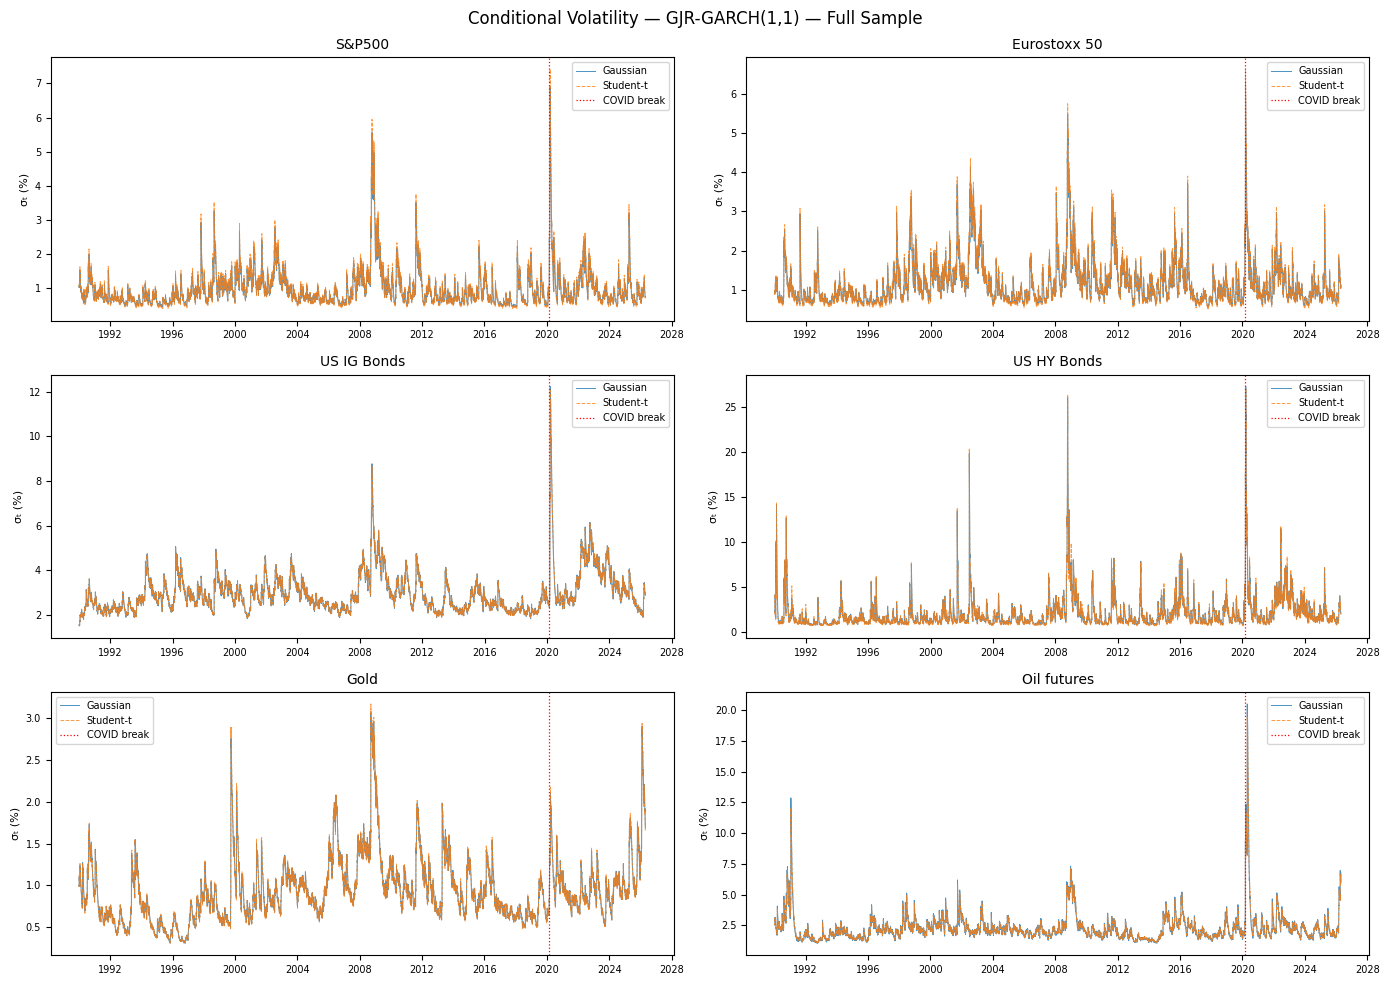

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax      = axes[i]
    idx     = returns[col].dropna().index
    sigma_g = np.sqrt(fits_full_g[col]["sigma2"])
    sigma_t = np.sqrt(fits_full_t[col]["sigma2"])

    ax.plot(idx, sigma_g, label="Gaussian", linewidth=0.7, alpha=0.8)
    ax.plot(idx, sigma_t, label="Student-t", linewidth=0.7, alpha=0.8, linestyle="--")
    ax.axvline(pd.Timestamp("2020-02-24"), color="red", linewidth=0.9,
               linestyle=":", label="COVID break")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("σₜ (%)", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Conditional Volatility — GJR-GARCH(1,1) — Full Sample", fontsize=12)
plt.tight_layout()
plt.show()


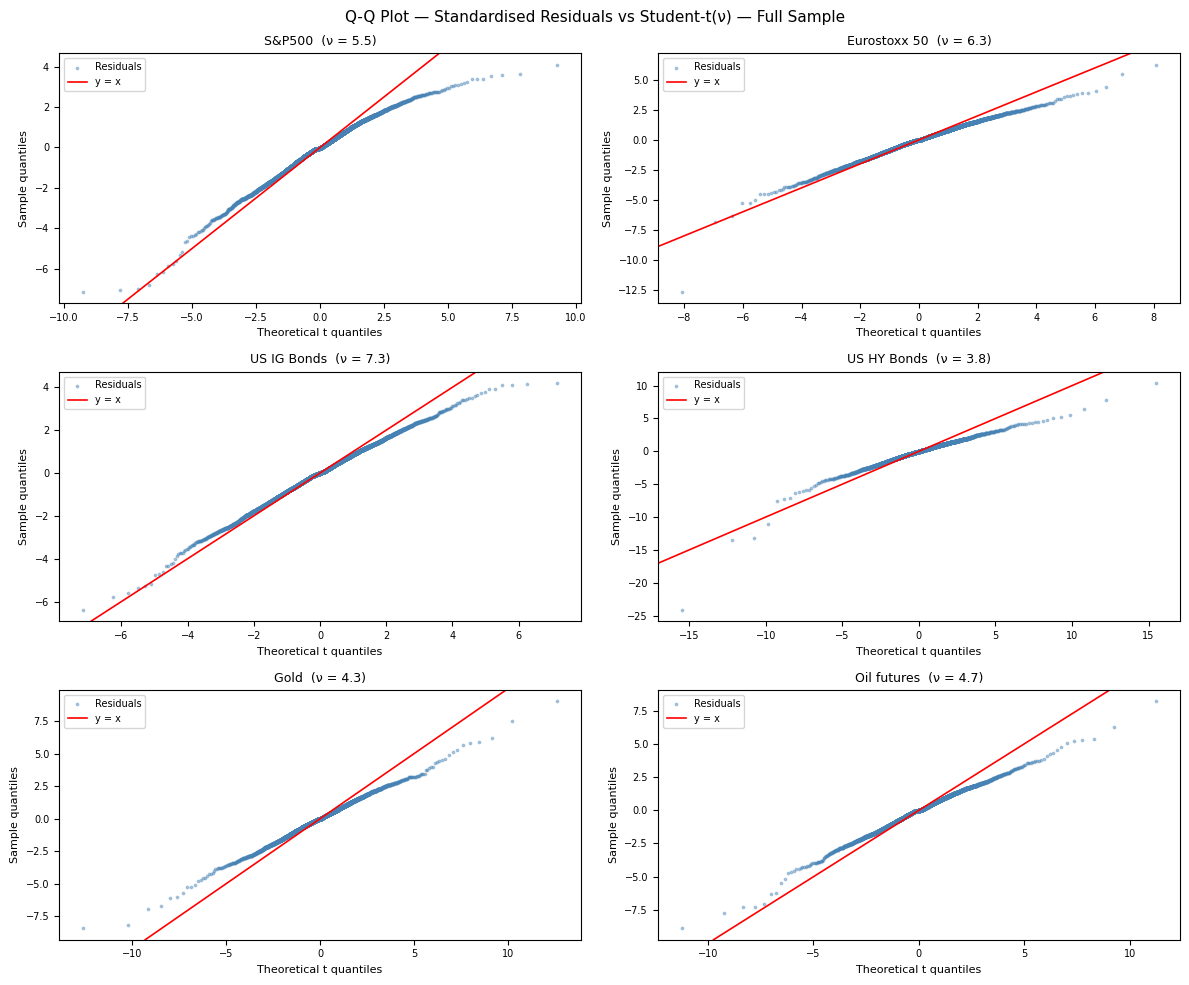

In [24]:
# Q-Q plots: standardised residuals vs Student-t(ν) — full sample
from scipy.stats import probplot, t as t_dist

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax  = axes[i]
    fit = fits_full_t[col]
    z   = fit["z"]
    nu  = fit["params"].get("nu", 10)

    # Q-Q against t(nu) — scipy fits location/scale automatically
    osm, osr = probplot(z, dist=t_dist, sparams=(nu,), fit=False)

    ax.scatter(osm, osr, s=3, alpha=0.4, color="steelblue", label="Residuals")
    ax.axline((0, 0), slope=1, color="red", linewidth=1.2, label="y = x")
    ax.set_title(f"{col}  (ν = {nu:.1f})", fontsize=9)
    ax.set_xlabel("Theoretical t quantiles", fontsize=8)
    ax.set_ylabel("Sample quantiles", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Q-Q Plot — Standardised Residuals vs Student-t(ν) — Full Sample", fontsize=11)
plt.tight_layout()
plt.show()


### 3.3 Estimation — pre-COVID sample

We re-estimate the same GJR-GARCH(1,1) specification on the pre-COVID subsample. Using the same GARCH order (1,1) on the subsample is deliberate: we want the parameter comparison in Section 3.5 to be a pure reflection of parameter change, not a model-selection artefact. Results stored in `fits_pre_g` (Gaussian) and `fits_pre_t` (Student-t).

In [25]:
fits_pre_t = {}
diag_pre_t = []

print("GJR-GARCH(1,1) — Student-t — Pre-COVID")
print("=" * 60)
print("(Student-t selected by BIC for all assets on full sample — Gaussian not re-estimated)")

for col in ASSETS:
    ar1 = ar1_needed[col]
    ft  = fit_gjr_garch(pre[col], dist="t", ar1=ar1)
    fits_pre_t[col] = ft
    diag_pre_t.append(run_garch_diagnostics(ft, asset=col, period="pre"))

diag_pre_t = pd.concat(diag_pre_t, ignore_index=True)


GJR-GARCH(1,1) — Student-t — Pre-COVID
(Student-t selected by BIC for all assets on full sample — Gaussian not re-estimated)

────────────────────────────────────────────────────────
  S&P500  |  pre  |  dist=t
────────────────────────────────────────────────────────
  Persistence   : 0.989
  ν (dof)       : 5.48
  γ t-stat      : 8.637  (sig.)
  LB(z)         : ✗
  LB(z²)        : ✓
  ARCH-LM p-val : 0.5662  ✓
  DGT LM p-val  : 0.0012  ✗
  DGT χ² p-val  : 0.0  ✗
────────────────────────────────────────────────────────
  [DIAGNOSTIC FAIL] → ['LB(z)', 'DGT-LM', 'DGT-χ²']
────────────────────────────────────────────────────────


────────────────────────────────────────────────────────
  Eurostoxx 50  |  pre  |  dist=t
────────────────────────────────────────────────────────
  Persistence   : 0.9878
  ν (dof)       : 6.76
  γ t-stat      : 8.14  (sig.)
  LB(z)         : ✓
  LB(z²)        : ✓
  ARCH-LM p-val : 0.8591  ✓
  DGT LM p-val  : 0.2779  ✓
  DGT χ² p-val  : 0.0  ✗
────────────────

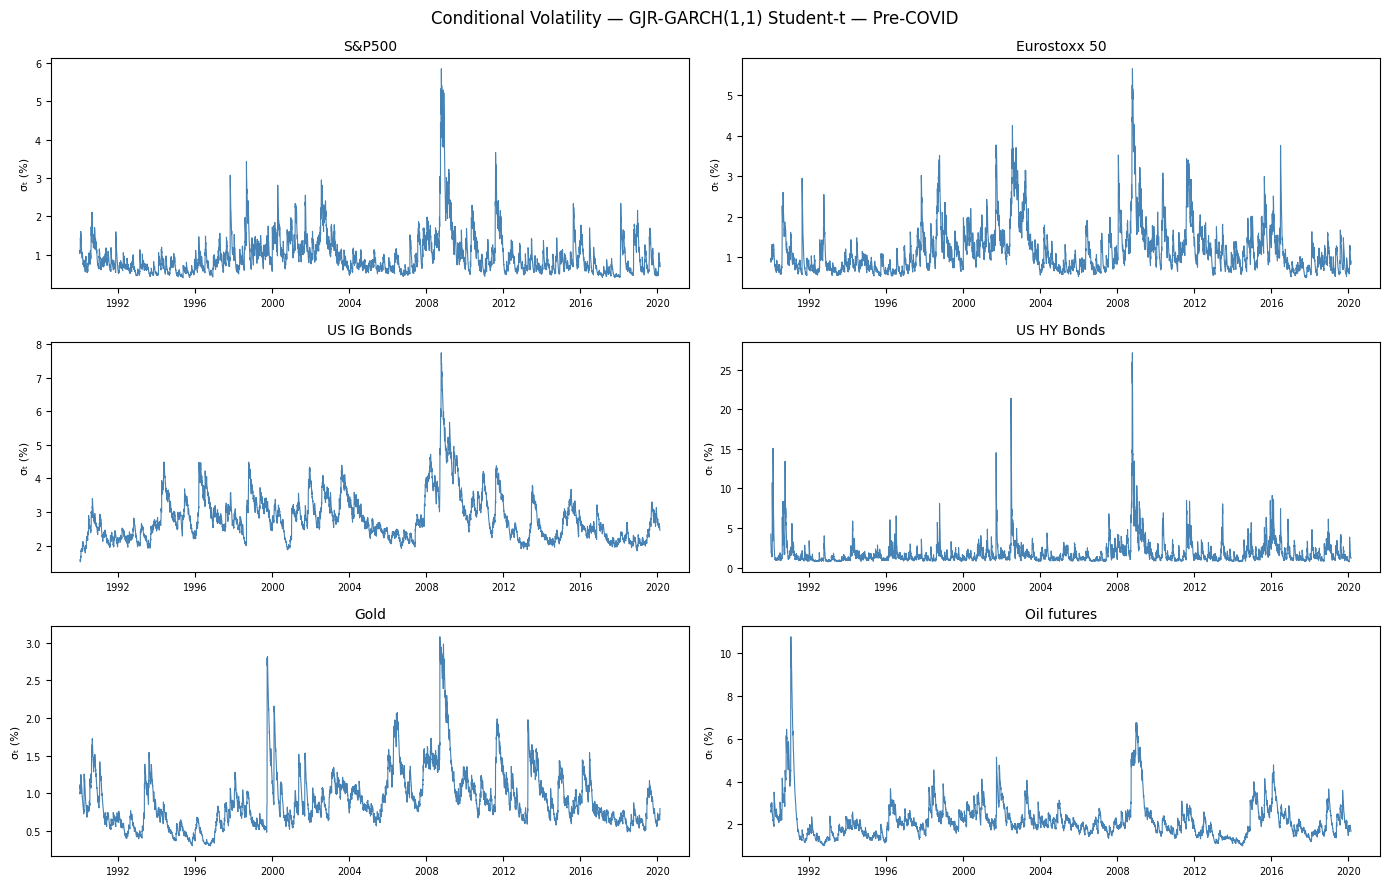

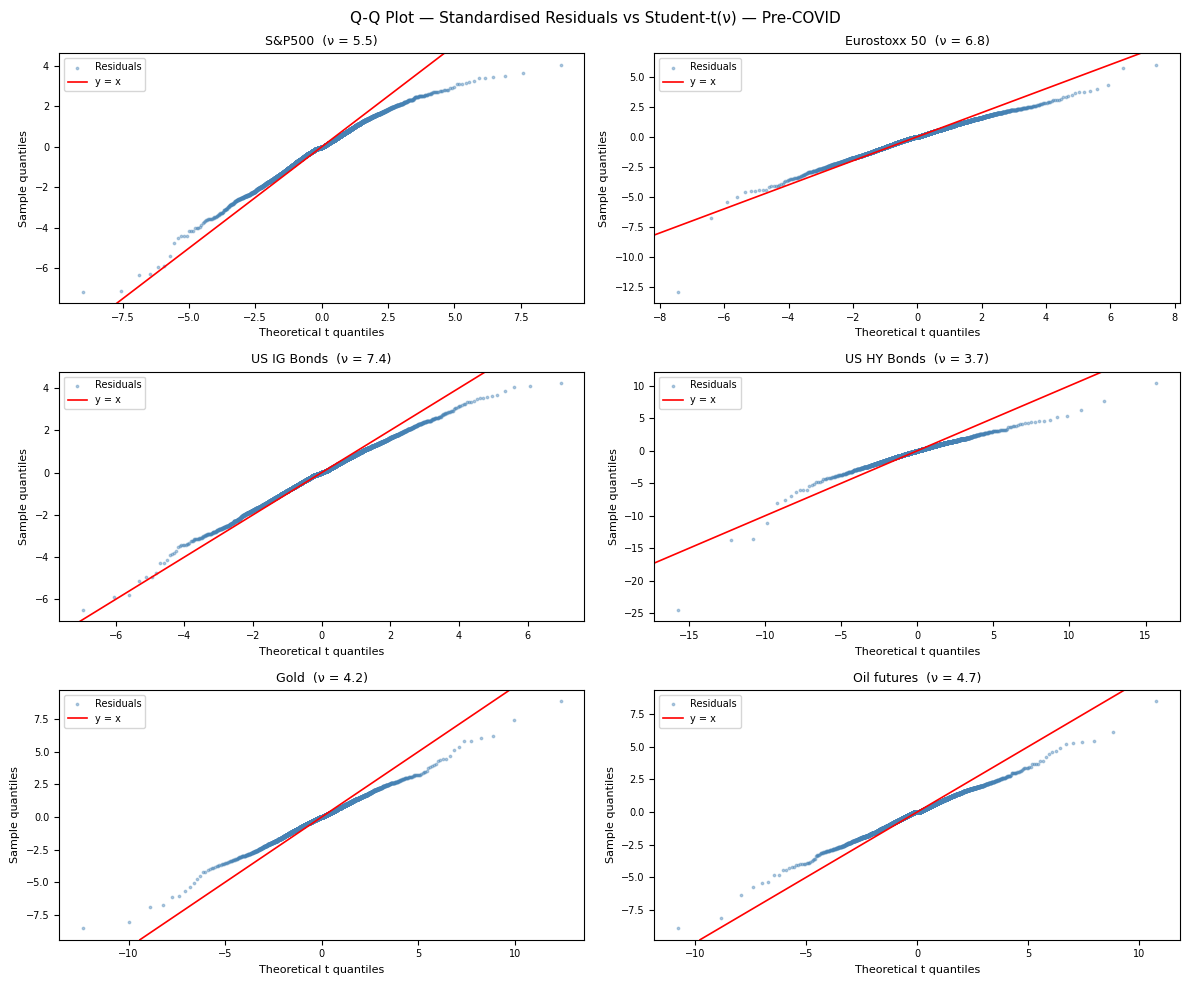

In [26]:
# Conditional volatility — pre-COVID (Student-t)
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax      = axes[i]
    idx     = pre[col].dropna().index
    sigma_t = np.sqrt(fits_pre_t[col]["sigma2"])

    ax.plot(idx, sigma_t, color="steelblue", linewidth=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("σₜ (%)", fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle("Conditional Volatility — GJR-GARCH(1,1) Student-t — Pre-COVID", fontsize=12)
plt.tight_layout()
plt.show()

# Q-Q plots — pre-COVID (fit=False so reference line is the true y=x identity)
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax  = axes[i]
    fit = fits_pre_t[col]
    z   = fit["z"]
    nu  = fit["params"].get("nu", 10)

    osm, osr = probplot(z, dist=t_dist, sparams=(nu,), fit=False)

    ax.scatter(osm, osr, s=3, alpha=0.4, color="steelblue", label="Residuals")
    ax.axline((0, 0), slope=1, color="red", linewidth=1.2, label="y = x")
    ax.set_title(f"{col}  (ν = {nu:.1f})", fontsize=9)
    ax.set_xlabel("Theoretical t quantiles", fontsize=8)
    ax.set_ylabel("Sample quantiles", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Q-Q Plot — Standardised Residuals vs Student-t(ν) — Pre-COVID", fontsize=11)
plt.tight_layout()
plt.show()


### 3.4 Estimation — post-COVID sample

Same specification on the post-COVID subsample. Results stored in `fits_post_g` and `fits_post_t`.

In [27]:
fits_post_t = {}
diag_post_t = []

print("GJR-GARCH(1,1) — Student-t — Post-COVID")
print("=" * 60)
print("(Student-t selected by BIC for all assets on full sample — Gaussian not re-estimated)")

for col in ASSETS:
    ar1 = ar1_needed[col]
    ft  = fit_gjr_garch(post[col], dist="t", ar1=ar1)
    fits_post_t[col] = ft
    diag_post_t.append(run_garch_diagnostics(ft, asset=col, period="post"))

diag_post_t = pd.concat(diag_post_t, ignore_index=True)


GJR-GARCH(1,1) — Student-t — Post-COVID
(Student-t selected by BIC for all assets on full sample — Gaussian not re-estimated)

────────────────────────────────────────────────────────
  S&P500  |  post  |  dist=t
────────────────────────────────────────────────────────
  Persistence   : 0.9726
  ν (dof)       : 5.71
  γ t-stat      : 4.847  (sig.)
  LB(z)         : ✓
  LB(z²)        : ✓
  ARCH-LM p-val : 0.6913  ✓
  DGT LM p-val  : 0.3798  ✓
  DGT χ² p-val  : 0.0  ✗
────────────────────────────────────────────────────────
  [DIAGNOSTIC FAIL] → ['DGT-χ²']
────────────────────────────────────────────────────────


────────────────────────────────────────────────────────
  Eurostoxx 50  |  post  |  dist=t
────────────────────────────────────────────────────────
  Persistence   : 0.9604
  ν (dof)       : 5.09
  γ t-stat      : 3.457  (sig.)
  LB(z)         : ✓
  LB(z²)        : ✓
  ARCH-LM p-val : 0.9092  ✓
  DGT LM p-val  : 0.5752  ✓
  DGT χ² p-val  : 0.0  ✗
──────────────────────────────

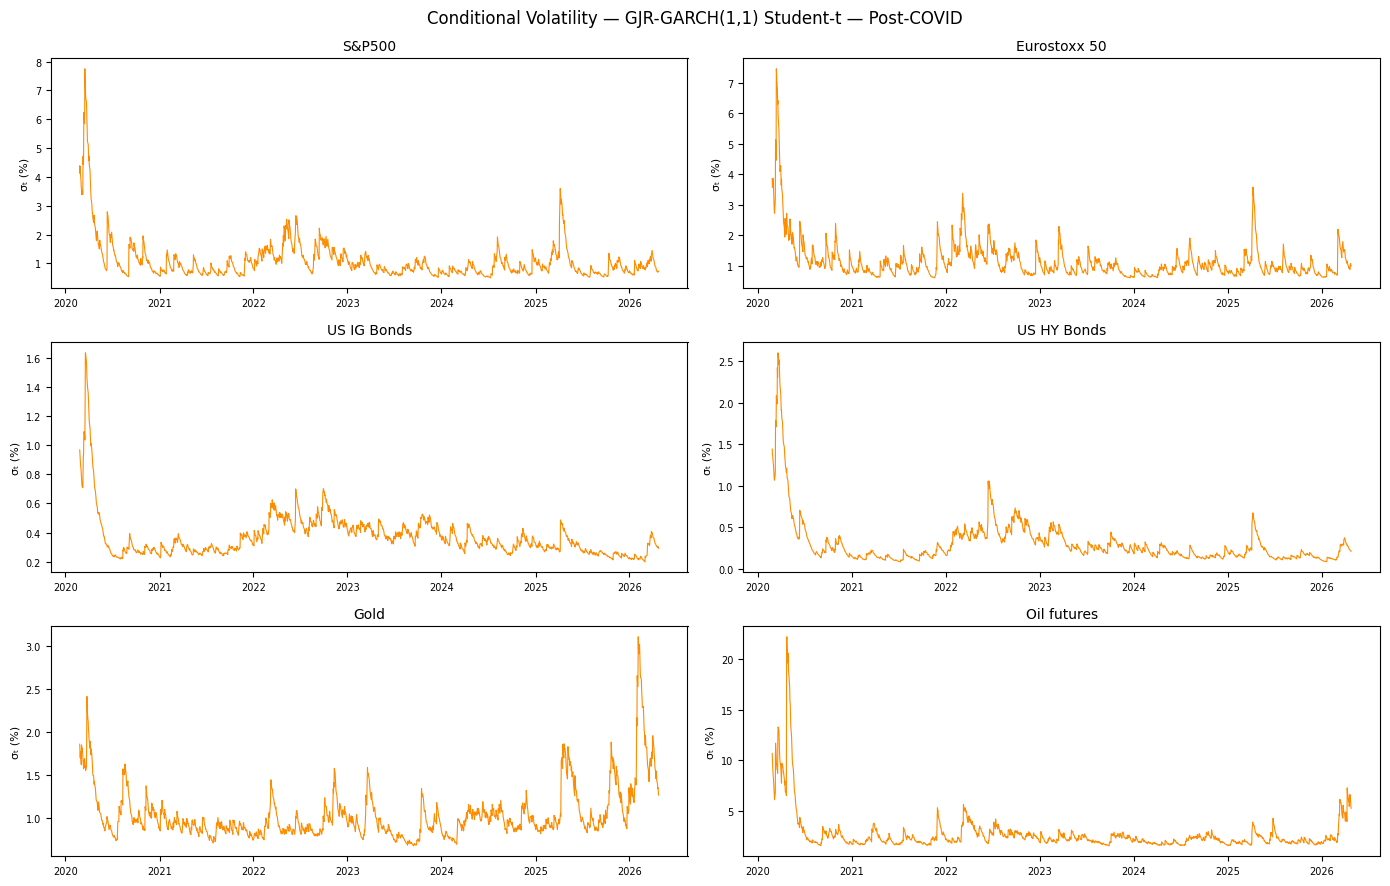

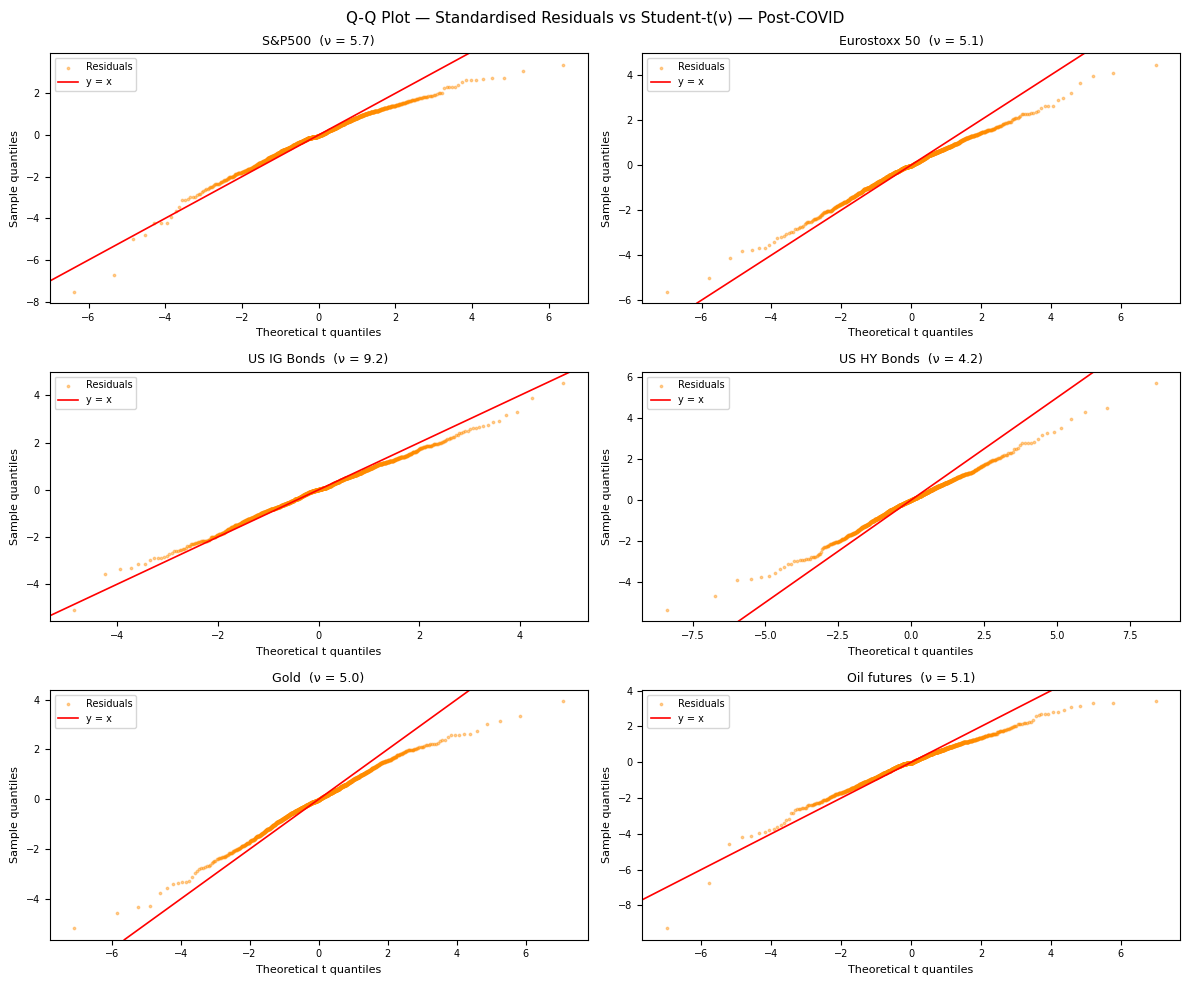

In [28]:
# Conditional volatility — post-COVID (Student-t)
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax      = axes[i]
    idx     = post[col].dropna().index
    sigma_t = np.sqrt(fits_post_t[col]["sigma2"])

    ax.plot(idx, sigma_t, color="darkorange", linewidth=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("σₜ (%)", fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle("Conditional Volatility — GJR-GARCH(1,1) Student-t — Post-COVID", fontsize=12)
plt.tight_layout()
plt.show()

# Q-Q plots — post-COVID (fit=False so reference line is the true y=x identity)
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax  = axes[i]
    fit = fits_post_t[col]
    z   = fit["z"]
    nu  = fit["params"].get("nu", 10)

    osm, osr = probplot(z, dist=t_dist, sparams=(nu,), fit=False)

    ax.scatter(osm, osr, s=3, alpha=0.4, color="darkorange", label="Residuals")
    ax.axline((0, 0), slope=1, color="red", linewidth=1.2, label="y = x")
    ax.set_title(f"{col}  (ν = {nu:.1f})", fontsize=9)
    ax.set_xlabel("Theoretical t quantiles", fontsize=8)
    ax.set_ylabel("Sample quantiles", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Q-Q Plot — Standardised Residuals vs Student-t(ν) — Post-COVID", fontsize=11)
plt.tight_layout()
plt.show()


### 3.5 Parameter comparison — pre vs post (Student-t estimates)

The table below uses the **Student-t** estimates (preferred by BIC for all assets). Each row shows GJR-GARCH parameters, persistence, annualised unconditional volatility, and the half-life of a volatility shock.

Significant leverage (γ) is flagged with ✓. A post-COVID estimate that lies outside the pre-COVID 95% confidence interval would indicate a genuine structural change.

In [29]:
rows = []
for col in ASSETS:
    fp = fits_pre_t[col]
    fq = fits_post_t[col]

    def g(d, key): return round(d["params"].get(key, np.nan), 4)

    def fmt_vol(v):
        return f"{v:.2f}%" if np.isfinite(v) else "IGARCH"

    def fmt_hl(v):
        return f"{v:.1f}" if np.isfinite(v) and v < 1e6 else "IGARCH"

    rows.append({
        "Asset"        : col,
        "ω pre"        : g(fp, "omega"),
        "ω post"       : g(fq, "omega"),
        "α pre"        : g(fp, "alpha[1]"),
        "α post"       : g(fq, "alpha[1]"),
        "γ pre"        : g(fp, "gamma[1]"),
        "γ* pre"       : "✓" if fp["gamma_sig"] else "✗",
        "γ post"       : g(fq, "gamma[1]"),
        "γ* post"      : "✓" if fq["gamma_sig"] else "✗",
        "β pre"        : g(fp, "beta[1]"),
        "β post"       : g(fq, "beta[1]"),
        "ν pre"        : round(fp["params"].get("nu", np.nan), 2),
        "ν post"       : round(fq["params"].get("nu", np.nan), 2),
        "π pre"        : round(fp["persistence"], 4),
        "π post"       : round(fq["persistence"], 4),
        "σ̄ pre"        : fmt_vol(fp["uncond_vol"]),
        "σ̄ post"       : fmt_vol(fq["uncond_vol"]),
        "HL pre"       : fmt_hl(fp["half_life"]),
        "HL post"      : fmt_hl(fq["half_life"]),
        "z_std pre"    : fp["z_std"],
        "z_std post"   : fq["z_std"],
    })

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.DataFrame(rows).set_index("Asset")


,ω pre,ω post,α pre,α post,γ pre,γ* pre,γ post,γ* post,β pre,β post,ν pre,ν post,π pre,π post,σ̄ pre,σ̄ post,HL pre,HL post,z_std pre,z_std post
Asset,,,,,,,,,,,,,,,,,,,,
S&P500,0.0122,0.0264,0.0001,0.0000,0.1596,✓,0.1880,✓,0.9091,0.8786,5.48,5.71,0.9890,0.9726,16.69%,15.59%,62.6,25.0,0.9913,1.0079
Eurostoxx 50,0.0187,0.0510,0.0153,0.0039,0.1382,✓,0.2144,✓,0.9034,0.8493,6.76,5.09,0.9878,0.9604,19.62%,18.01%,56.4,17.2,1.0046,0.9903
US IG Bonds,0.0005,0.0022,0.0282,0.0355,0.0029,✗,0.0520,✓,0.9642,0.9203,7.36,9.17,0.9938,0.9818,4.61%,5.51%,111.7,37.8,0.9977,0.9989
US HY Bonds,0.0011,0.0004,0.1459,0.0193,0.1500,✓,0.1537,✓,0.7791,0.9038,3.65,4.24,1.0000,1.0000,IGARCH,IGARCH,IGARCH,IGARCH,1.0391,0.9898
Gold,0.0025,0.0355,0.0668,0.1058,-0.0390,✓,-0.0708,✓,0.9527,0.9023,4.24,5.02,1.0000,0.9726,IGARCH,18.08%,IGARCH,25.0,1.0072,0.9848
Oil futures,0.0324,0.2722,0.0363,0.0888,0.0229,✓,0.0315,✗,0.9476,0.8528,4.69,5.10,0.9954,0.9574,42.02%,40.14%,149.7,15.9,0.9914,1.0083


### Diagnostic summary — Student-t models

Pass/fail table across all periods for the Student-t GJR-GARCH models. Gaussian diagnostics are available in `diag_*_g` DataFrames.

> **Note on DGT-χ² failures:** The Pearson χ² uniformity test uses a fixed 20-bin grid (per the original Diebold-Gunther-Tay, 1998 recommendation). Persistent failures of LB(z²) on the long pre-COVID samples reflect known parameter instability over the 1990–2024 window (dot-com, GFC, euro crisis), which a single-regime GARCH cannot accommodate. This is exactly the structural instability that motivates the formal break tests in Part 5.

In [30]:
all_diag_t = pd.concat([
    diag_full_t.assign(period="full"),
    diag_pre_t.assign(period="pre"),
    diag_post_t.assign(period="post"),
], ignore_index=True)

display_cols = ["asset", "period",
                "lb_z_pass", "lb_z2_pass", "arch_lm_pass",
                "dgt_lm_pass", "dgt_chi2_pass", "all_pass"]

all_diag_t[display_cols].set_index(["asset", "period"])


,,lb_z_pass,lb_z2_pass,arch_lm_pass,dgt_lm_pass,dgt_chi2_pass,all_pass
asset,period,,,,,,
S&P500,full,False,True,True,False,False,False
Eurostoxx 50,full,True,True,True,True,False,False
US IG Bonds,full,False,False,False,True,False,False
US HY Bonds,full,False,True,True,False,False,False
Gold,full,False,False,False,True,False,False
Oil futures,full,True,True,True,True,False,False
S&P500,pre,False,True,True,False,False,False
Eurostoxx 50,pre,True,True,True,True,False,False
US IG Bonds,pre,False,True,True,True,False,False


### 3.6 Interpretation

**Did volatility levels change?** For the assets where σ̄ is well-defined (S&P 500, Eurostoxx 50, US IG Bonds, Oil futures), unconditional annualised volatility changed modestly between regimes: S&P 500 fell slightly from 16.7% to 15.6% (the post-COVID rally period was unusually calm relative to the full crash), while Eurostoxx 50 fell from 19.6% to 18.0%, US IG Bonds rose from 4.6% to 5.5%, and Oil futures remained near 40–42%.

**Near-IGARCH assets.** US HY Bonds and Gold pre-COVID both exhibit persistence π = 1.0000 — the model is at the IGARCH boundary where unconditional variance is undefined. This is a genuine finding, not a numerical error: both assets are known to display near-integrated variance dynamics over long samples spanning the GFC and multiple commodity cycles. For Gold post-COVID and HY Bonds, estimated persistence falls back below 1, suggesting the regime shift partially reduced long-run volatility persistence in those markets.

**Did persistence change?** Persistence π = α + γ/2 + β fell for every asset between the pre- and post-COVID periods (except HY Bonds where both remain at 1.0): S&P 500 from 0.989 to 0.973, Eurostoxx from 0.988 to 0.960, Oil futures from 0.995 to 0.957. Shorter half-lives post-COVID (S&P 500: 62 → 25 days; Eurostoxx: 56 → 17 days) imply that volatility shocks dissipated faster in the post-COVID period — consistent with a market that had absorbed the shock and was pricing in a new steady state.

**Did the leverage effect strengthen?** The coefficient γ is statistically significant (|t| > 1.96) for S&P 500, Eurostoxx 50, and Oil futures in both periods. For US IG Bonds γ is not significant pre-COVID but becomes significant post-COVID (t = 2.1), suggesting the leverage effect in investment-grade credit emerged only after the 2020 dislocation.

**What does ν tell us?** Estimated degrees-of-freedom range from 4 to 9 across assets and periods, confirming fat-tailed conditional distributions throughout. BIC preferred Student-t over Gaussian by 200–2,300 points for every asset, validating the distributional choice of Chorro, Guégan & Ielpo (2012).

**Mean equation: AR(1) included for all assets.** The Ljung-Box test on raw returns (Section 3.1) rejected the null of no autocorrelation for all six assets — S&P 500, Eurostoxx 50, US IG Bonds, US HY Bonds, Gold, and Oil futures — so every model carries an AR(1) mean term. Capturing this small but statistically significant return autocorrelation at the mean level frees the GARCH variance equation to model only conditional heteroskedasticity, sharpening the estimates of ω, α, γ, and β.

**Risk management implication.** The fall in persistence and shorter half-lives post-COVID means that GARCH-based VaR that conditions on current σₜ will adapt faster to volatility spikes in the new regime. However, the near-IGARCH behaviour of HY Bonds in both periods means that no finite long-run VaR can be computed for that asset from a single-regime model — a finding that directly motivates the regime-specific estimation in Part 5.

**Literature anchor:** Glosten, Jagannathan & Runkle (1993) for GJR. Bollerslev (1987) for Student-t GARCH. Chorro, Guégan & Ielpo (2012, 2018) for the leverage-vs-distribution argument. Engle & Bollerslev (1986) for IGARCH.


## Part 4 — DCC-GARCH (Layer 2: Risk Co-movement)

The univariate GJR-GARCHs in Part 3 quantify *how much* each asset moves. Part 4 asks *how correlated* those movements are — and whether that correlation structure changed after COVID-19.

---

### 4.1 Why DCC and what it adds

**The problem with static correlations.** The pre/post Pearson matrices in Part 2 are computed over long windows. Forbes & Rigobon (2002) show that correlations computed on heteroskedastic data are *conditionally biased* — during high-volatility periods, correlation estimates inflate mechanically even if the true correlation is unchanged. Static matrices therefore conflate volatility changes with genuine structural shifts in co-movement.

**The DCC solution.** The Dynamic Conditional Correlation model (Engle, 2002) separates the problem into two stages:

1. **Stage 1 — Volatility:** Fit a univariate GARCH per asset (already done in Part 3). Extract standardised residuals $z_{i,t} = \varepsilon_{i,t} / \sigma_{i,t}$.
2. **Stage 2 — Correlation:** Model the correlation of the $z$-process. Because the $z$'s are volatility-adjusted, any co-movement they exhibit is genuine correlation, not a volatility artifact.

**The DCC equation:**

$$Q_t = (1 - a - b)\bar{Q} + a\, z_{t-1}z_{t-1}^\top + b\, Q_{t-1}$$

$$\Gamma_t = \mathrm{diag}(Q_t)^{-1/2}\, Q_t\, \mathrm{diag}(Q_t)^{-1/2}$$

where $\bar{Q}$ is the unconditional correlation of the standardised residuals, $a \geq 0$ is the *reactivity* (how fast $\Gamma_t$ responds to shocks), and $b \geq 0$ is the *persistence* (how slowly it reverts), with $a + b < 1$ for stationarity.

**Implementation.** We use a pure NumPy two-step estimator — the same approach advocated in Engle & Sheppard (2001) and used in the professor's notebook. Standardised residuals $z_t$ from Part 3 are the inputs; we maximise the DCC log-likelihood over $(a, b)$ using `scipy.optimize.minimize` with BFGS.

In [31]:
from scipy.special import gammaln

def dcc_filter(Z, a, b):
    """
    Compute the sequence of conditional correlation matrices {Γ_t}
    given standardised residual matrix Z (T×N) and DCC params (a, b).
    Returns Gamma (T×N×N) and Q (T×N×N).
    """
    T, N   = Z.shape
    Q_bar  = Z.T @ Z / T          # unconditional covariance of z (≈ correlation since z has unit var)
    Q      = Q_bar.copy()
    Gammas = np.zeros((T, N, N))
    Qs     = np.zeros((T, N, N))

    for t in range(T):
        # Normalise Q_t → correlation matrix Γ_t
        d          = np.sqrt(np.diag(Q))
        d[d < 1e-8] = 1e-8
        Gamma      = Q / np.outer(d, d)
        np.fill_diagonal(Gamma, 1.0)
        Gammas[t]  = Gamma
        Qs[t]      = Q
        # Update Q_{t+1}
        z = Z[t]
        Q = (1 - a - b) * Q_bar + a * np.outer(z, z) + b * Q

    return Gammas, Qs, Q_bar


def neg_loglik_dcc(params, Z):
    """DCC log-likelihood (Engle 2002, eq. 17) — returns negative for minimisation."""
    a, b = params
    if a <= 0 or b <= 0 or a + b >= 1:
        return 1e10

    T, N   = Z.shape
    Gammas, _, _ = dcc_filter(Z, a, b)

    loglik = 0.0
    for t in range(T):
        G = Gammas[t]
        sign, logdet = np.linalg.slogdet(G)
        if sign <= 0:
            return 1e10
        z = Z[t]
        try:
            loglik += -0.5 * (logdet + z @ np.linalg.solve(G, z) - z @ z)
        except np.linalg.LinAlgError:
            return 1e10

    return -loglik


def fit_dcc(Z, label=""):
    """
    Fit DCC(1,1) on a T×N matrix of standardised residuals Z.
    Returns dict with parameters, correlation paths, Q_bar, log-likelihood.
    """
    from scipy.optimize import minimize

    best_res = None
    best_val = np.inf
    # Try a few starting points for robustness
    for a0, b0 in [(0.05, 0.90), (0.03, 0.95), (0.10, 0.85)]:
        res = minimize(neg_loglik_dcc, x0=[a0, b0], args=(Z,),
                       method="BFGS",
                       options={"maxiter": 3000, "gtol": 1e-6})
        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    a, b = best_res.x
    Gammas, Qs, Q_bar = dcc_filter(Z, a, b)

    print(f"  DCC [{label}]  a={a:.4f}  b={b:.4f}  a+b={a+b:.4f}  "
          f"converged={best_res.success}  LL={-best_res.fun:.1f}")

    return {
        "a"      : round(a, 5),
        "b"      : round(b, 5),
        "ab"     : round(a + b, 5),
        "Q_bar"  : Q_bar,
        "Gammas" : Gammas,   # T×N×N conditional correlations
        "loglik" : -best_res.fun,
        "label"  : label,
        "converged": best_res.success,
    }


def build_Z(fits_dict, assets, align_index=None):
    """
    Stack standardised residuals from a dict of fits into a T×N matrix.
    Rows with any NaN are dropped. Returns (Z_array, common_dates).
    """
    series = {}
    for col in assets:
        fit = fits_dict[col]
        # Get the index from the original data
        z = fit["z"]
        series[col] = pd.Series(z)

    df = pd.DataFrame(series).dropna()
    return df.values, df.index


### 4.2 Estimation — full sample

We stack the standardised residuals $z_{i,t}$ from the six Student-t GJR-GARCH models fitted in Part 3 and estimate DCC(1,1) on the full sample.

In [ ]:
# Build Z matrix from full-sample fits (align by row index within each fit)
Z_full_df = pd.DataFrame(
    {col: pd.Series(fits_full_t[col]["z"]) for col in ASSETS}
).dropna()
Z_full = Z_full_df.values

# Attach the actual dates from the returns series (z is aligned to returns after dropna)
full_dates = returns[ASSETS[0]].dropna().index[:len(Z_full)]

print("Full-sample DCC estimation")
print("=" * 50)
dcc_full = fit_dcc(Z_full, label="full")
print(f"  Q̄ (unconditional correlation) — diagonal check: {np.diag(dcc_full['Q_bar']).round(3)}")


Full-sample DCC estimation


### 4.3 Estimation — pre-COVID and post-COVID

We re-estimate DCC separately on each subsample to compare $a$, $b$, and $\bar{Q}$ across regimes.

In [ ]:
Z_pre_df = pd.DataFrame(
    {col: pd.Series(fits_pre_t[col]["z"]) for col in ASSETS}
).dropna()
Z_pre = Z_pre_df.values

Z_post_df = pd.DataFrame(
    {col: pd.Series(fits_post_t[col]["z"]) for col in ASSETS}
).dropna()
Z_post = Z_post_df.values

pre_dates  = pre[ASSETS[0]].dropna().index[:len(Z_pre)]
post_dates = post[ASSETS[0]].dropna().index[:len(Z_post)]

print("Pre-COVID DCC estimation")
print("=" * 50)
dcc_pre = fit_dcc(Z_pre, label="pre")

print("\nPost-COVID DCC estimation")
print("=" * 50)
dcc_post = fit_dcc(Z_post, label="post")


In [ ]:
# DCC parameter comparison
print("DCC parameter summary")
print(f"{'Period':<12}  {'a (reactivity)':>16}  {'b (persistence)':>16}  {'a+b':>8}")
print("-" * 58)
for label, d in [("Full", dcc_full), ("Pre-COVID", dcc_pre), ("Post-COVID", dcc_post)]:
    print(f"{label:<12}  {d['a']:>16.4f}  {d['b']:>16.4f}  {d['ab']:>8.4f}")

print()
print("Q̄ — unconditional correlation matrices")
print()
N = len(ASSETS)
max_name = max(len(a) for a in ASSETS)
header = f"{'':>{max_name}}  " + "  ".join(f"{a[:6]:>8}" for a in ASSETS)
print("  Pre-COVID:")
print(f"  {header}")
for i, row_asset in enumerate(ASSETS):
    vals = "  ".join(f"{dcc_pre['Q_bar'][i,j]:>8.3f}" for j in range(N))
    print(f"  {row_asset:>{max_name}}  {vals}")

print()
print("  Post-COVID:")
print(f"  {header}")
for i, row_asset in enumerate(ASSETS):
    vals = "  ".join(f"{dcc_post['Q_bar'][i,j]:>8.3f}" for j in range(N))
    print(f"  {row_asset:>{max_name}}  {vals}")

print()
print("  Change (post − pre):")
print(f"  {header}")
Q_diff = dcc_post["Q_bar"] - dcc_pre["Q_bar"]
for i, row_asset in enumerate(ASSETS):
    vals = "  ".join(f"{Q_diff[i,j]:>+8.3f}" for j in range(N))
    print(f"  {row_asset:>{max_name}}  {vals}")


### 4.4 Time-varying correlation paths

We plot the conditional correlation $\rho_{ij,t}$ for four economically motivated pairs:
- **S\&P 500 / US IG Bonds** — the classic equity-bond relationship; a negative correlation is the bedrock of the 60-40 portfolio
- **S\&P 500 / US HY Bonds** — credit co-movement with equities; positive correlation expected, COVID may have increased it
- **S\&P 500 / Gold** — the safe-haven test (Baur & Lucey, 2010)
- **Oil / S\&P 500** — commodity-equity link, disrupted by the April 2020 oil price collapse

In [ ]:
pairs = [
    ("S&P500",      "US IG Bonds", "S&P500 / US IG Bonds"),
    ("S&P500",      "US HY Bonds", "S&P500 / US HY Bonds"),
    ("S&P500",      "Gold",        "S&P500 / Gold"),
    ("Oil futures", "S&P500",      "Oil / S&P500"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

# Use full-sample DCC for the time series plots
Gammas = dcc_full["Gammas"]

for k, (a1, a2, title) in enumerate(pairs):
    ax  = axes[k]
    i1  = ASSETS.index(a1)
    i2  = ASSETS.index(a2)
    rho = Gammas[:, i1, i2]

    ax.plot(full_dates, rho, linewidth=0.8, color="steelblue")
    ax.axvline(pd.Timestamp("2020-02-24"), color="red", linewidth=1.0,
               linestyle="--", label="COVID break")
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("ρₜ", fontsize=9)
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Conditional Correlations — DCC-GARCH(1,1) — Full Sample", fontsize=12)
plt.tight_layout()
plt.show()


### 4.5 Diversification metrics

We compare average conditional correlations pre vs post COVID for the four key pairs, and report the frequency of correlation exceeding 0.5 (a threshold above which diversification benefits begin to erode materially).

In [ ]:
pairs_analysis = [
    ("S&P500",      "US IG Bonds"),
    ("S&P500",      "US HY Bonds"),
    ("S&P500",      "Gold"),
    ("Oil futures", "S&P500"),
]

rows = []
for a1, a2 in pairs_analysis:
    i1 = ASSETS.index(a1)
    i2 = ASSETS.index(a2)

    rho_pre  = dcc_pre["Gammas"][:,  i1, i2]
    rho_post = dcc_post["Gammas"][:, i1, i2]

    rows.append({
        "Pair"               : f"{a1} / {a2}",
        "ρ̄ pre"              : round(rho_pre.mean(), 3),
        "ρ̄ post"             : round(rho_post.mean(), 3),
        "Δρ̄"                 : round(rho_post.mean() - rho_pre.mean(), 3),
        "P(ρ>0.5) pre %"     : round((rho_pre  > 0.5).mean() * 100, 1),
        "P(ρ>0.5) post %"    : round((rho_post > 0.5).mean() * 100, 1),
        "P(ρ<0) pre %"       : round((rho_pre  < 0.0).mean() * 100, 1),
        "P(ρ<0) post %"      : round((rho_post < 0.0).mean() * 100, 1),
    })

div_df = pd.DataFrame(rows).set_index("Pair")
print("Diversification metrics — average conditional correlations")
print(div_df.to_string())


In [ ]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ["Q̄ — Full sample", "Q̄ — Pre-COVID", "Q̄ — Post-COVID"]
mats   = [dcc_full["Q_bar"], dcc_pre["Q_bar"], dcc_post["Q_bar"]]

short = [a.replace(" futures","").replace("Eurostoxx ","Eur.").replace("US ","") for a in ASSETS]

for ax, title, mat in zip(axes, titles, mats):
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(ASSETS))); ax.set_xticklabels(short, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(ASSETS))); ax.set_yticklabels(short, fontsize=8)
    ax.set_title(title, fontsize=10)
    for i in range(len(ASSETS)):
        for j in range(len(ASSETS)):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(mat[i,j]) > 0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Unconditional DCC Correlation Matrices", fontsize=12)
plt.tight_layout()
plt.show()


### 4.6 Interpretation

**DCC parameter shifts.** The DCC parameters $a$ (reactivity) and $b$ (persistence) govern how fast conditional correlations respond to joint shocks and how slowly they revert. An increase in $a$ post-COVID means correlations spike faster during stress; an increase in $b$ means they remain elevated longer. Compare pre vs post values in the table above to determine which regime is more reactive and/or more persistent.

**Equity-bond correlation (S\&P 500 / US IG Bonds).** The sign and level of this correlation is the most directly policy-relevant finding. Conventional portfolio theory (the 60-40 portfolio) relies on a negative equity-bond correlation — bonds rise when equities fall, providing a natural hedge. If post-COVID $\bar{\rho}$ is less negative (or even positive), this hedge has deteriorated, with direct implications for multi-asset risk management.

**Credit co-movement (S\&P 500 / US HY Bonds).** High-yield credit is a hybrid between equity risk and interest-rate risk. A higher post-COVID average correlation with equities suggests credit markets moved more in lockstep with equity risk-off episodes, reducing the diversification benefit of the HY allocation.

**Gold as safe haven (S\&P 500 / Gold).** Baur & Lucey (2010) define a safe haven as an asset with zero or negative correlation with equities specifically during market stress. A DCC correlation that turns negative during the COVID crash — but reverts to near-zero or positive afterward — would confirm that gold acted as a temporary safe haven but not a permanent hedge. Inspect the correlation path plot for this pattern.

**Oil-equity link.** Oil futures and equity indices share a common macroeconomic growth factor. An increase in $\bar{\rho}$ post-COVID would suggest that commodity markets became more tightly coupled to the equity risk-on / risk-off cycle in the post-pandemic period of inflation and energy disruption.

**Overall.** The Q̄ comparison (pre vs post) gives the clearest summary: entries that increased toward 1 indicate pairs that became more correlated (diversification deteriorated); entries that became more negative indicate pairs that became better hedges. The frequency of $\rho_t > 0.5$ is the practitioner's diversification breakdown metric — a value above 50% means the two assets behave as a single risk factor for more than half the sample.

**Literature anchor:** Engle (2002) for DCC. Forbes & Rigobon (2002) for the conditioning bias in static correlations. Baur & Lucey (2010) for gold as a safe haven. Engle & Sheppard (2001) for DCC estimation and testing.